# [LAB-06] 3. KDE Plot

## #01. 준비작업

### 1. 패키지 가져오기

In [1]:
from jussam import load_data
from helper import *
import seaborn as sb

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 2. 데이터 가져오기

In [2]:
origin = load_data("iris")
origin.head()

📚 1936년 영국의 통계학자 로널드 피셔(Ronald A. Fisher)가 소개한 3가지 품종(setosa, versicolor, virginica)의 붓꽃(Iris)에 대한 꽃받침과 꽃잎의 길이와 너비 측정값으로 구성된 유명한 머신러닝 및 데이터 분석용 데이터셋.(출처: Kaggle)

    field         description
--  ------------  -------------
 0  Sepal.Length  꽃받침 길이
 1  Sepal.Width   꽃받침 너비
 2  Petal.Length  꽃잎 길이
 3  Petal.Width   꽃잎 너비
 4  Species       품종



,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.100,3.500,1.400,0.200,setosa
1,4.900,3.000,1.400,0.200,setosa
2,4.700,3.200,1.300,0.200,setosa
3,4.600,3.100,1.500,0.200,setosa
4,5.000,3.600,1.400,0.200,setosa


## #02. 일변량 커널 밀도

### 1. 단일 분포 --> 하나의 변수에 대한 KDE Plot

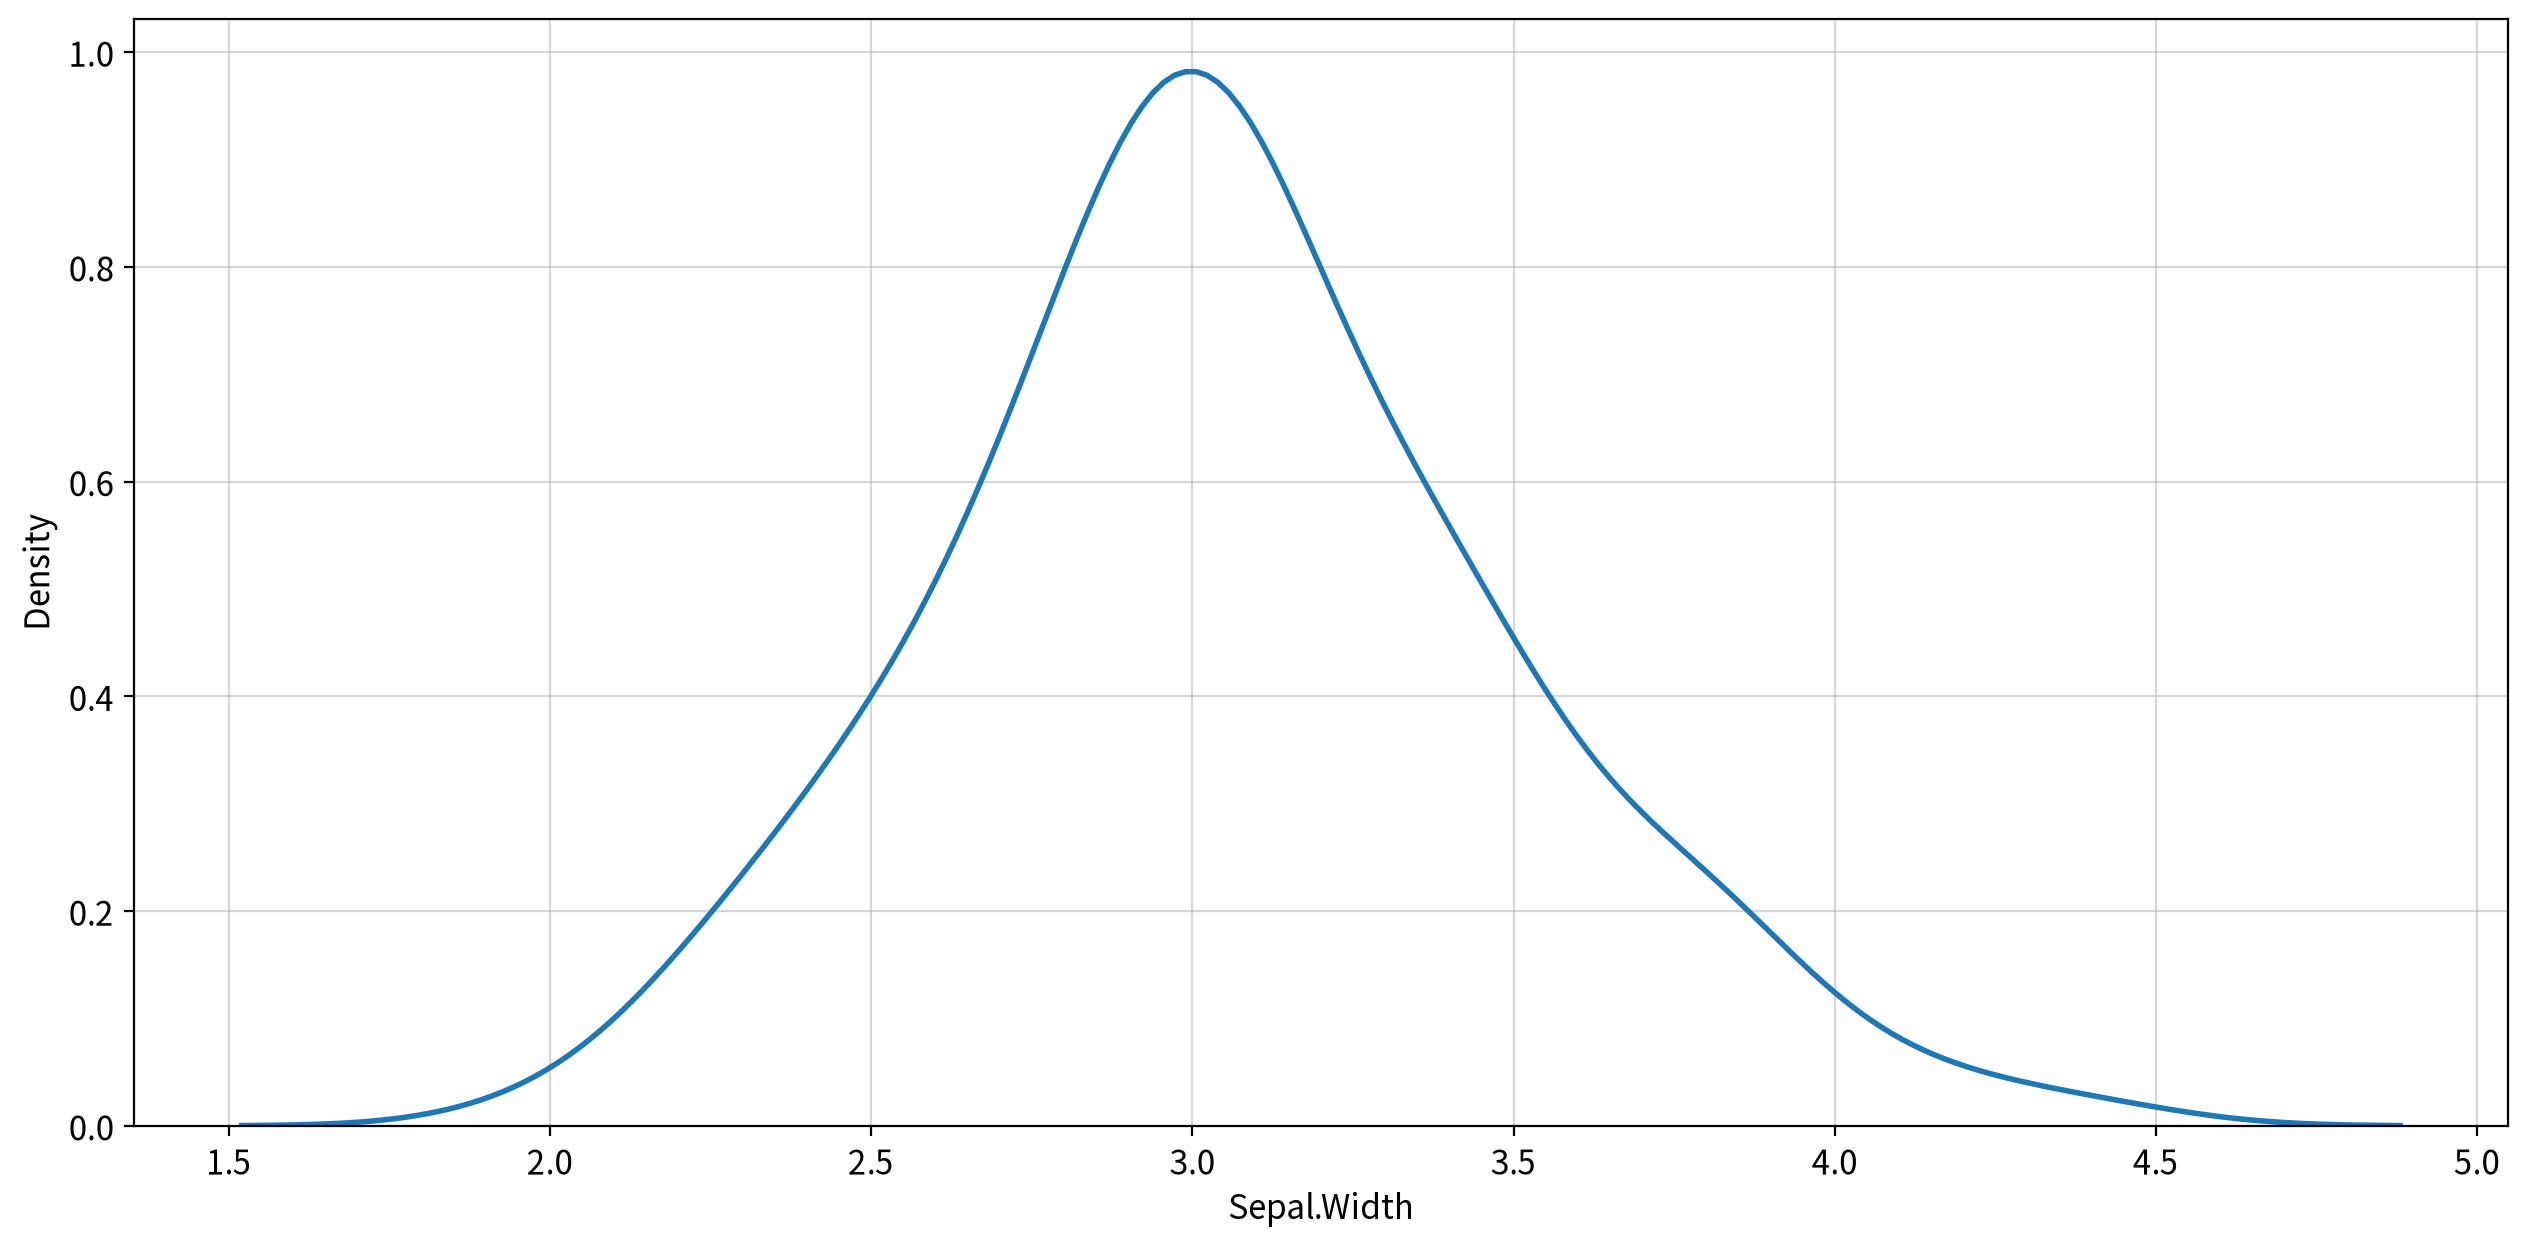

In [3]:
# 그래프 초기화
fig, ax = my_plot.init()

# 그래프 그리기 (아래 패턴 3가지는 모두 결과가 동일함)
# [패턴1] 자동인식 패턴
# sb.kdeplot(data=origin["Sepal.Width"])
# [패턴2] 개별 데이터 지정 패턴
# sb.kdeplot(x=origin["Sepal.Width"])
# [패턴3] DataFrame 지정 패턴
sb.kdeplot(data=origin, x= "Sepal.Width", linewidth=2)

# 출력
my_plot.show()

### 2. 다중 분포

- 데이터프레임을 data 파라미터에 적용하면서 x나 y파라미터를 지정하지 않으면 모든 연속형 변수에 대한 커널 밀도 곡선이 표현된다.

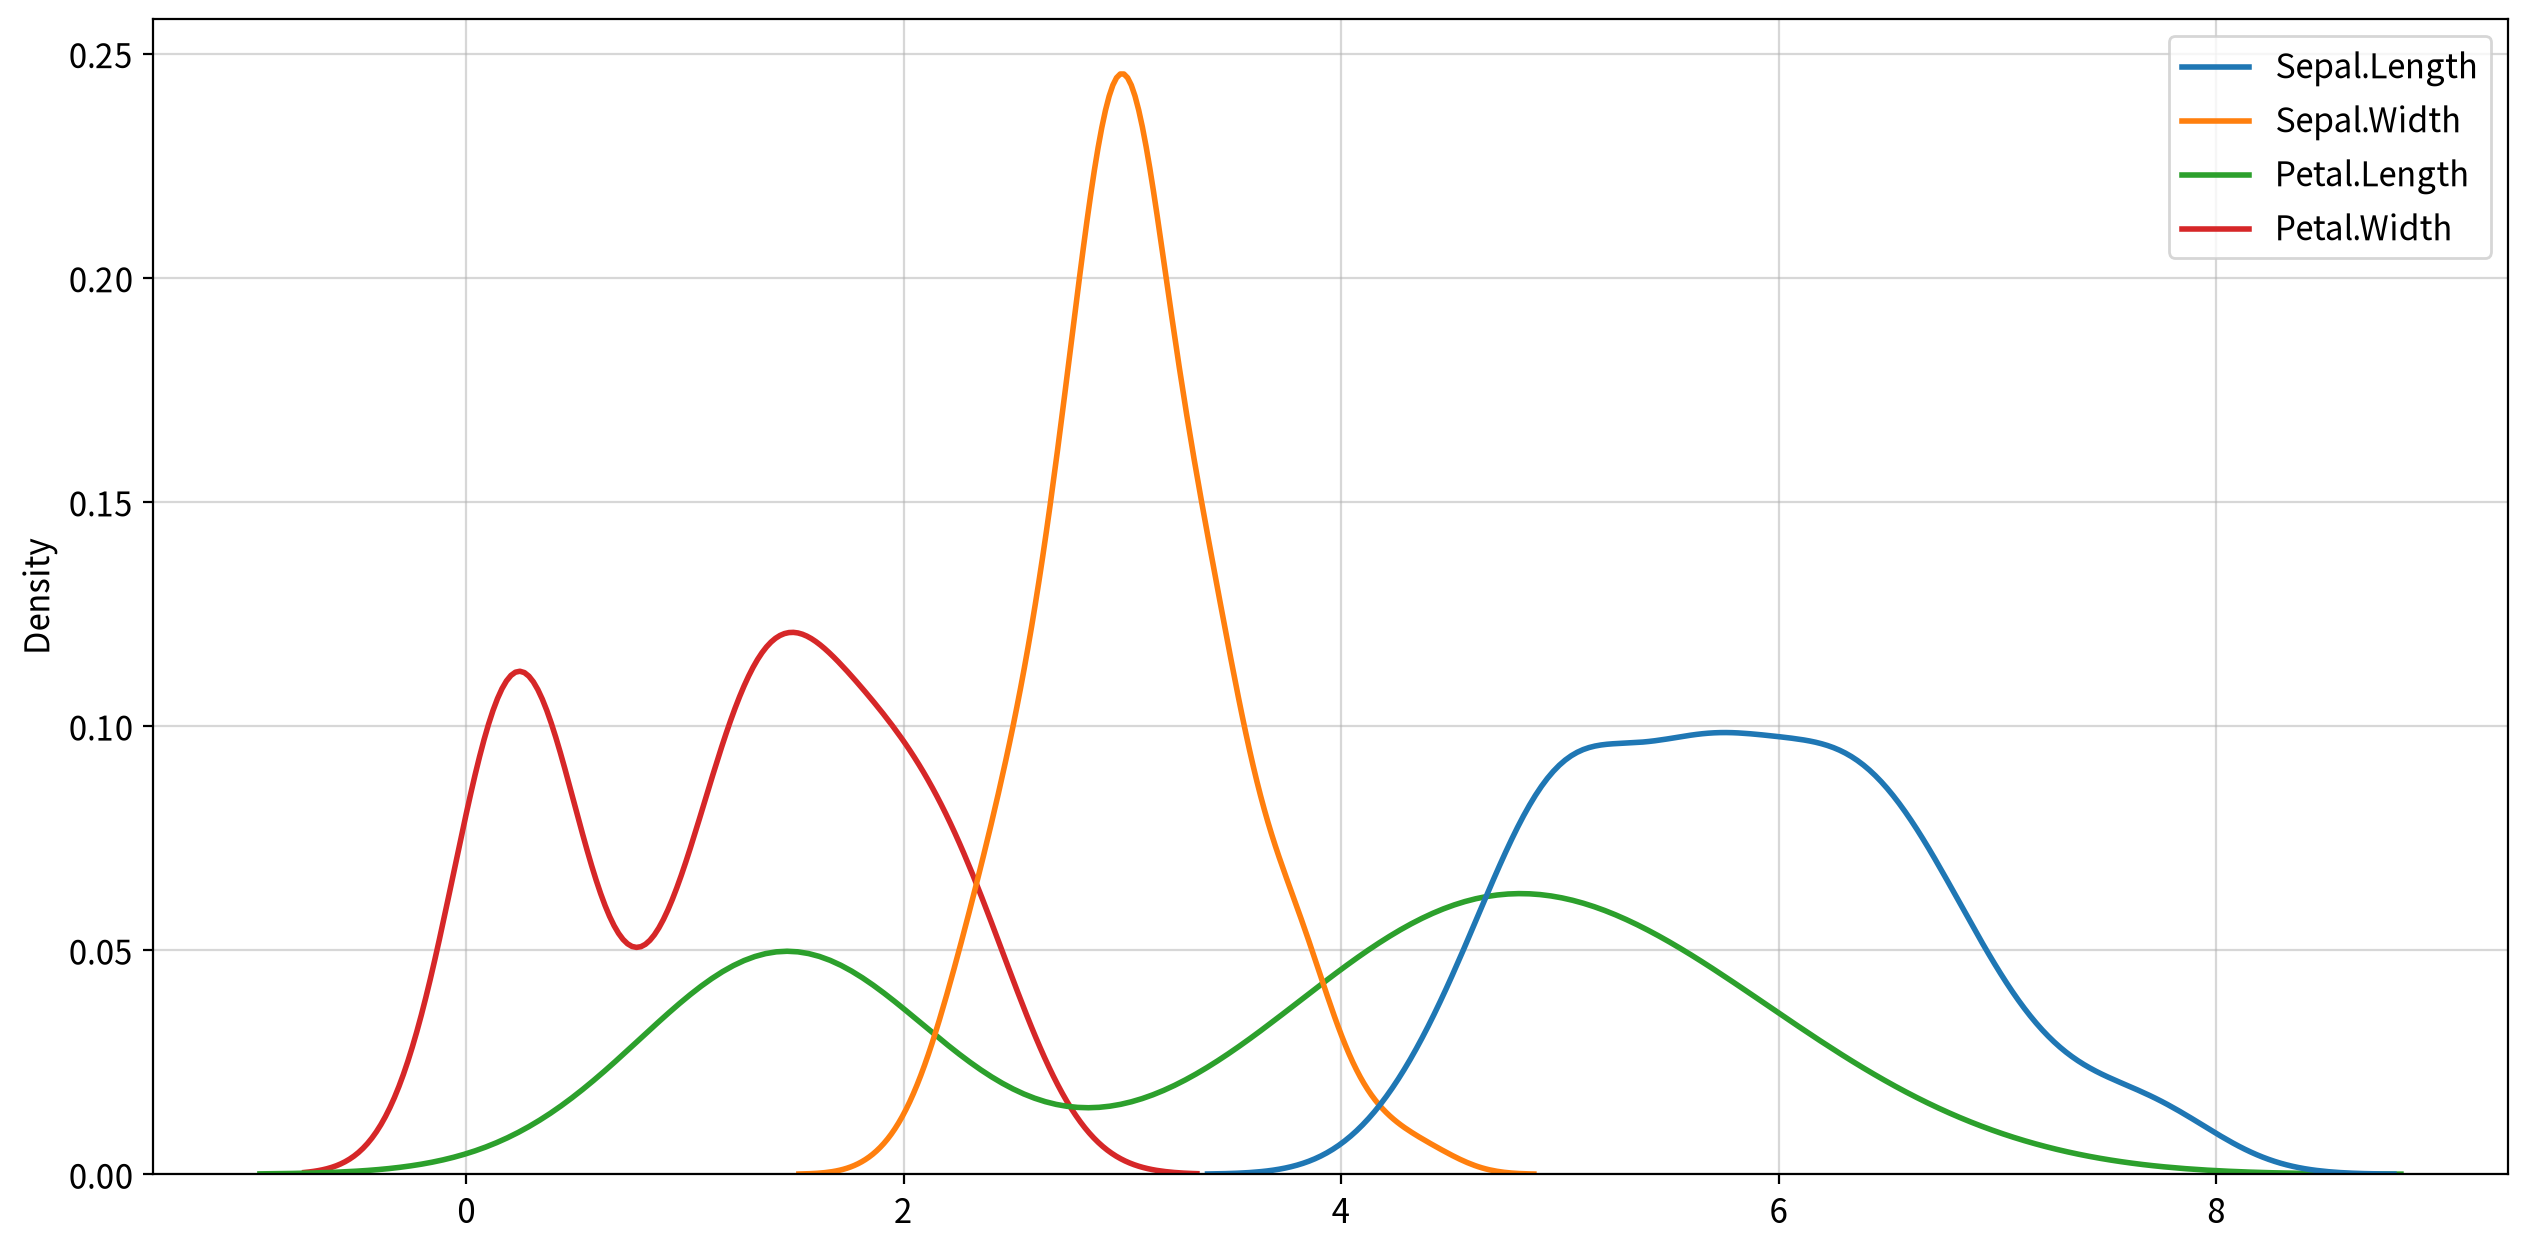

In [4]:
# 그래프 초기화
fig, ax = my_plot.init()

# 그래프 그리기 - x 대신 y를 설정할 경우 가로로 표시된다.
sb.kdeplot(data=origin)

# 출력
my_plot.show()

### 3. 옵션 설정

- **hue** : 명목형 변수를 지정하여 범주에 따라 그래프를 색상별로 분기한다.
- **fill=True** : 밀도 곡선의 내부 면적을 색상으로 채워 시각적 무게감을 부여한다.
- `alpha` : `0~1`사이의 값으로 면의 투명도를 조절한다. 
    - `0=투명`, `1=불투명`
- `palette` : 데이터 특성에 맞는 색상 팔레트를 지정한다.
  - ex: pastel, Blues 등

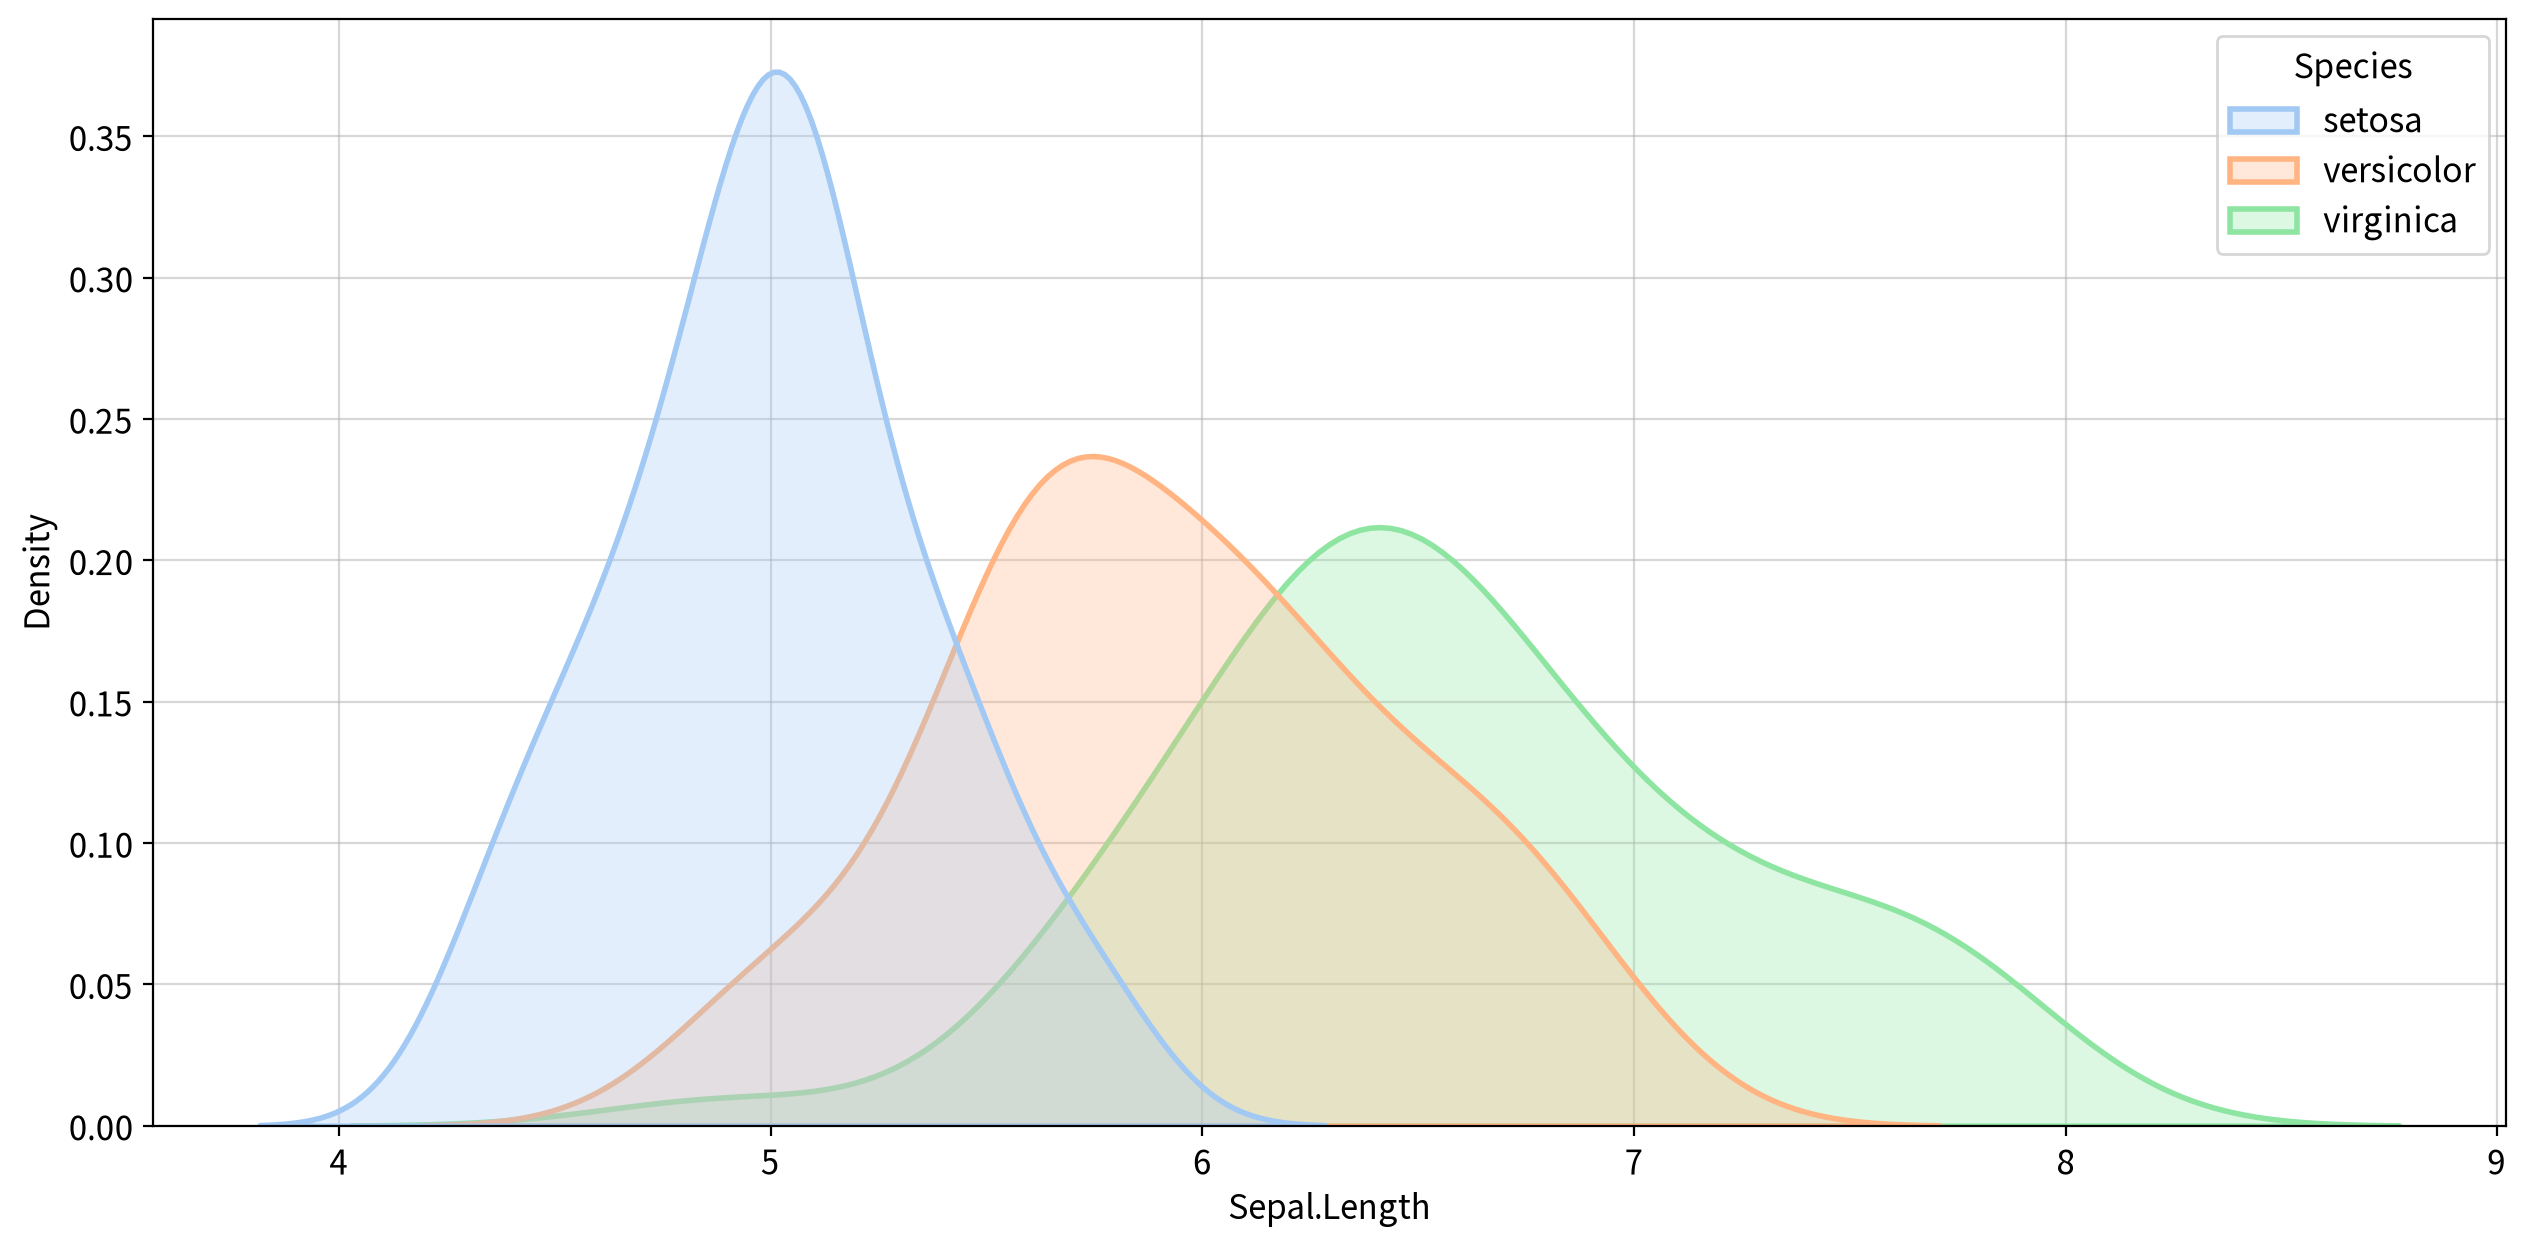

In [5]:
# 그래프 초기화
fig, ax = my_plot.init()

# 그래프 그리기 / x = Sepal.Length, 범주 = Species, 면채움, 투명도30%, 색상:pastel, 선두께:2
sb.kdeplot(
    data=origin,
    x='Sepal.Length',
    hue='Species',
    fill=True,
    alpha=0.3,
    palette='pastel',
    linewidth=2
)

# 출력
my_plot.show()

## #03. 이변량 커널밀도

### 1. x에 따른 y분포

- x 파라미터와 y파라미터를 모두 설정한다.

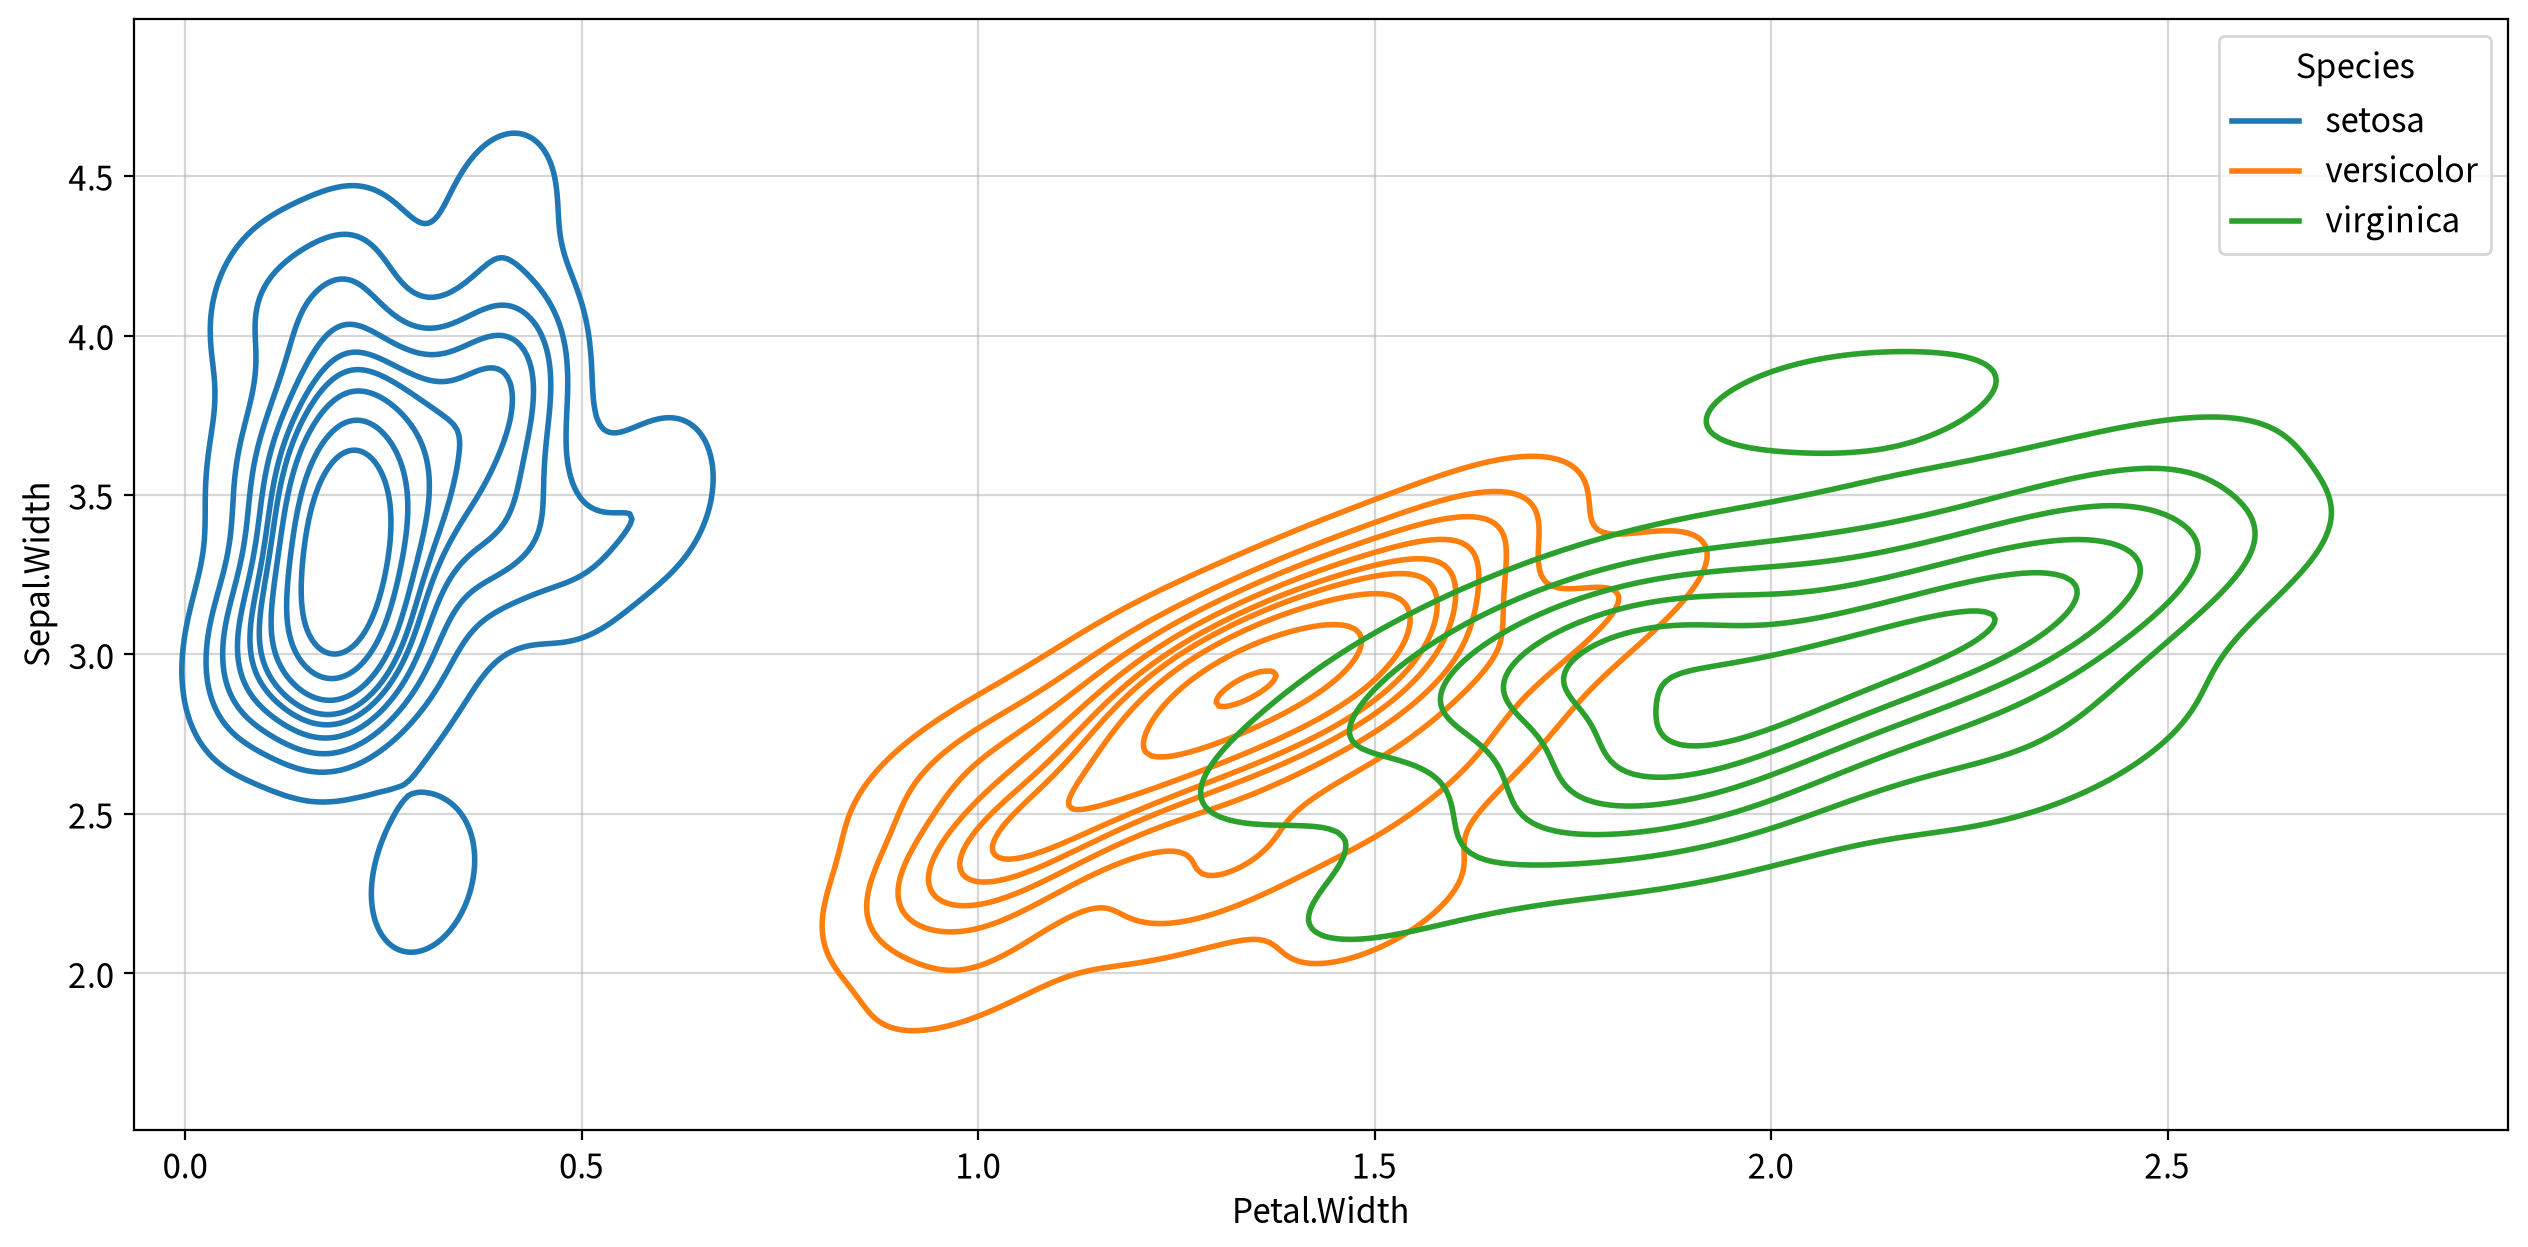

In [6]:
# 그래프 초기화
fig, ax = my_plot.init()

# 그래프 그리기
sb.kdeplot(data=origin, x="Petal.Width", y="Sepal.Width", hue='Species')

# 출력
my_plot.show()

#### 💡 인사이트

- Petal.Width 기준으로 setosa는 완전히 분리되며, versicolor와 virginica는 부분적으로 겹침

- 🔵 **setosa(파란색): 가장 좁은 꽃잎 폭(0~0.6) & 중간 정도의 꽃받침 폭(2.0~4.6)**
  - 가장 왼쪽에 집중된 분포로 다른 종과 명확하게 분리됨
- 🟠 **versicolor(주황색): 중간 크기의 꽃잎 폭(1.0~2.0) & 가장 좁은 꽃받침 폭(~3.5)**
  - setosa와 virginica 사이의 중간 특성을 보유
  - 두 종 사이에 겹치는 영역이 존재
- 🟢 **virginica(초록색): 가장 넓은 꽃잎 폭(2.0~2.5) & 중간~넓은 꽃받침 폭(2.5~4.0)**
  - 오른쪽 상단에 위치하여 다른 종과 구분됨

## #04. 커널밀도와 평균값을 함께 표시하기

### 1. 평균값 구하기

In [7]:
# Sepal.Width의 평균 구하기
mean_Sepal_Width = origin["Sepal.Width"].mean()
print(mean_Sepal_Width)

3.0573333333333337


### 2. 커널밀도 + 평균값

- **ax.axvline()** : x축 지점에 수직인 세로 직선을 그릴 수 있다.
- **ax.text()** : 특정 좌표 지점에 텍스트를 표시할 수 있다.

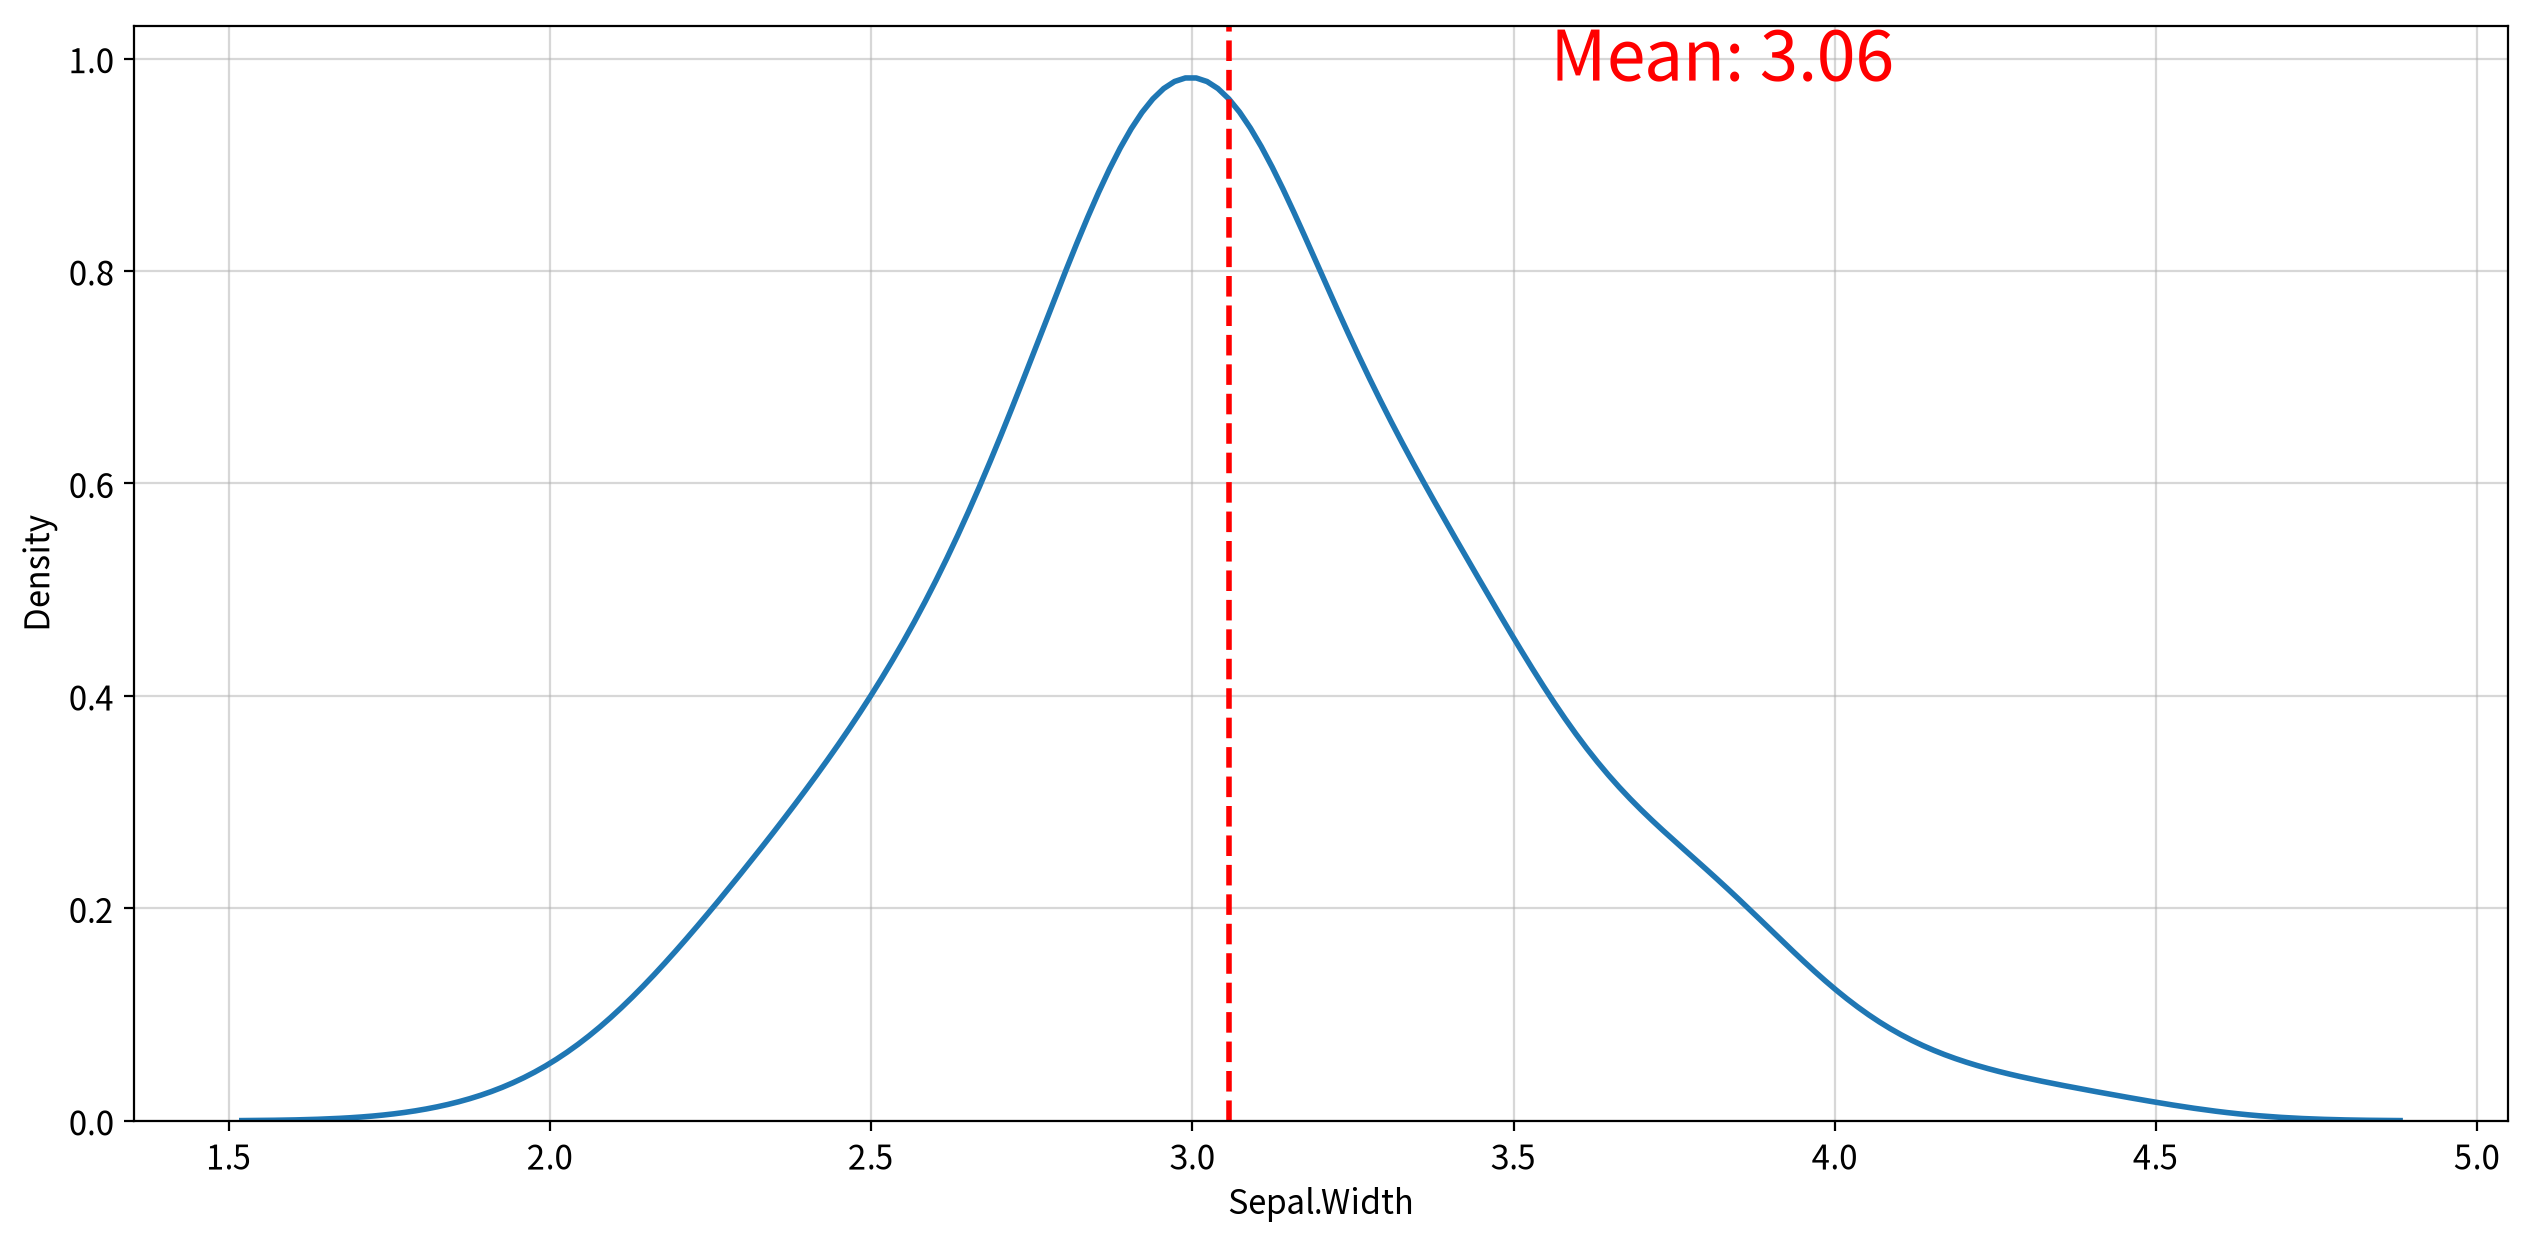

In [8]:
# 그래프 초기화
fig, ax = my_plot.init()

# 그래프 그리기
sb.kdeplot(origin, x="Sepal.Width")

# 평균에 대한 수직선 추가
ax.axvline(x=mean_Sepal_Width, linestyle="--", color="red")

# 텍스트 표시하기
ax.text(x=mean_Sepal_Width + 0.5, y=ax.get_ylim()[1]*0.95, s=f'Mean: {mean_Sepal_Width:.2f}', color="red", fontsize=25)
# 출력
my_plot.show()

#### 💡 인사이트

- 📊 **Sepal.Width의 분포는 대칭적인 종 모양의 단봉형 분포를 나타냄**

- 📍 **평균값(Mean: 3.06)이 분포의 최고점과 일치함**
  - 중앙에 위치한 수직선이 커널밀도 곡선의 피크와 겹침
  - 데이터가 평균을 중심으로 균형잡혀 분포함을 의미
- 📈 **분포의 범위는 약 1.5~5.0 사이에 집중**
  - 2.0~4.0 구간에 가장 높은 밀도로 관찰됨
  - 양쪽 끝으로 갈수록 밀도가 점진적으로 감소
- 🔔 **정규분포(Normal Distribution)에 가까운 형태**
  - 대칭성이 뚜렷하고 이상치(Outlier)가 거의 없음을 시사
- 🎯 **평균 3.06을 중심으로 ±0.5 범위(약 2.5~3.5)에 대부분의 데이터가 집중**

## #05. 모듈화 기능 확인

### 1. 단순 사용 방법

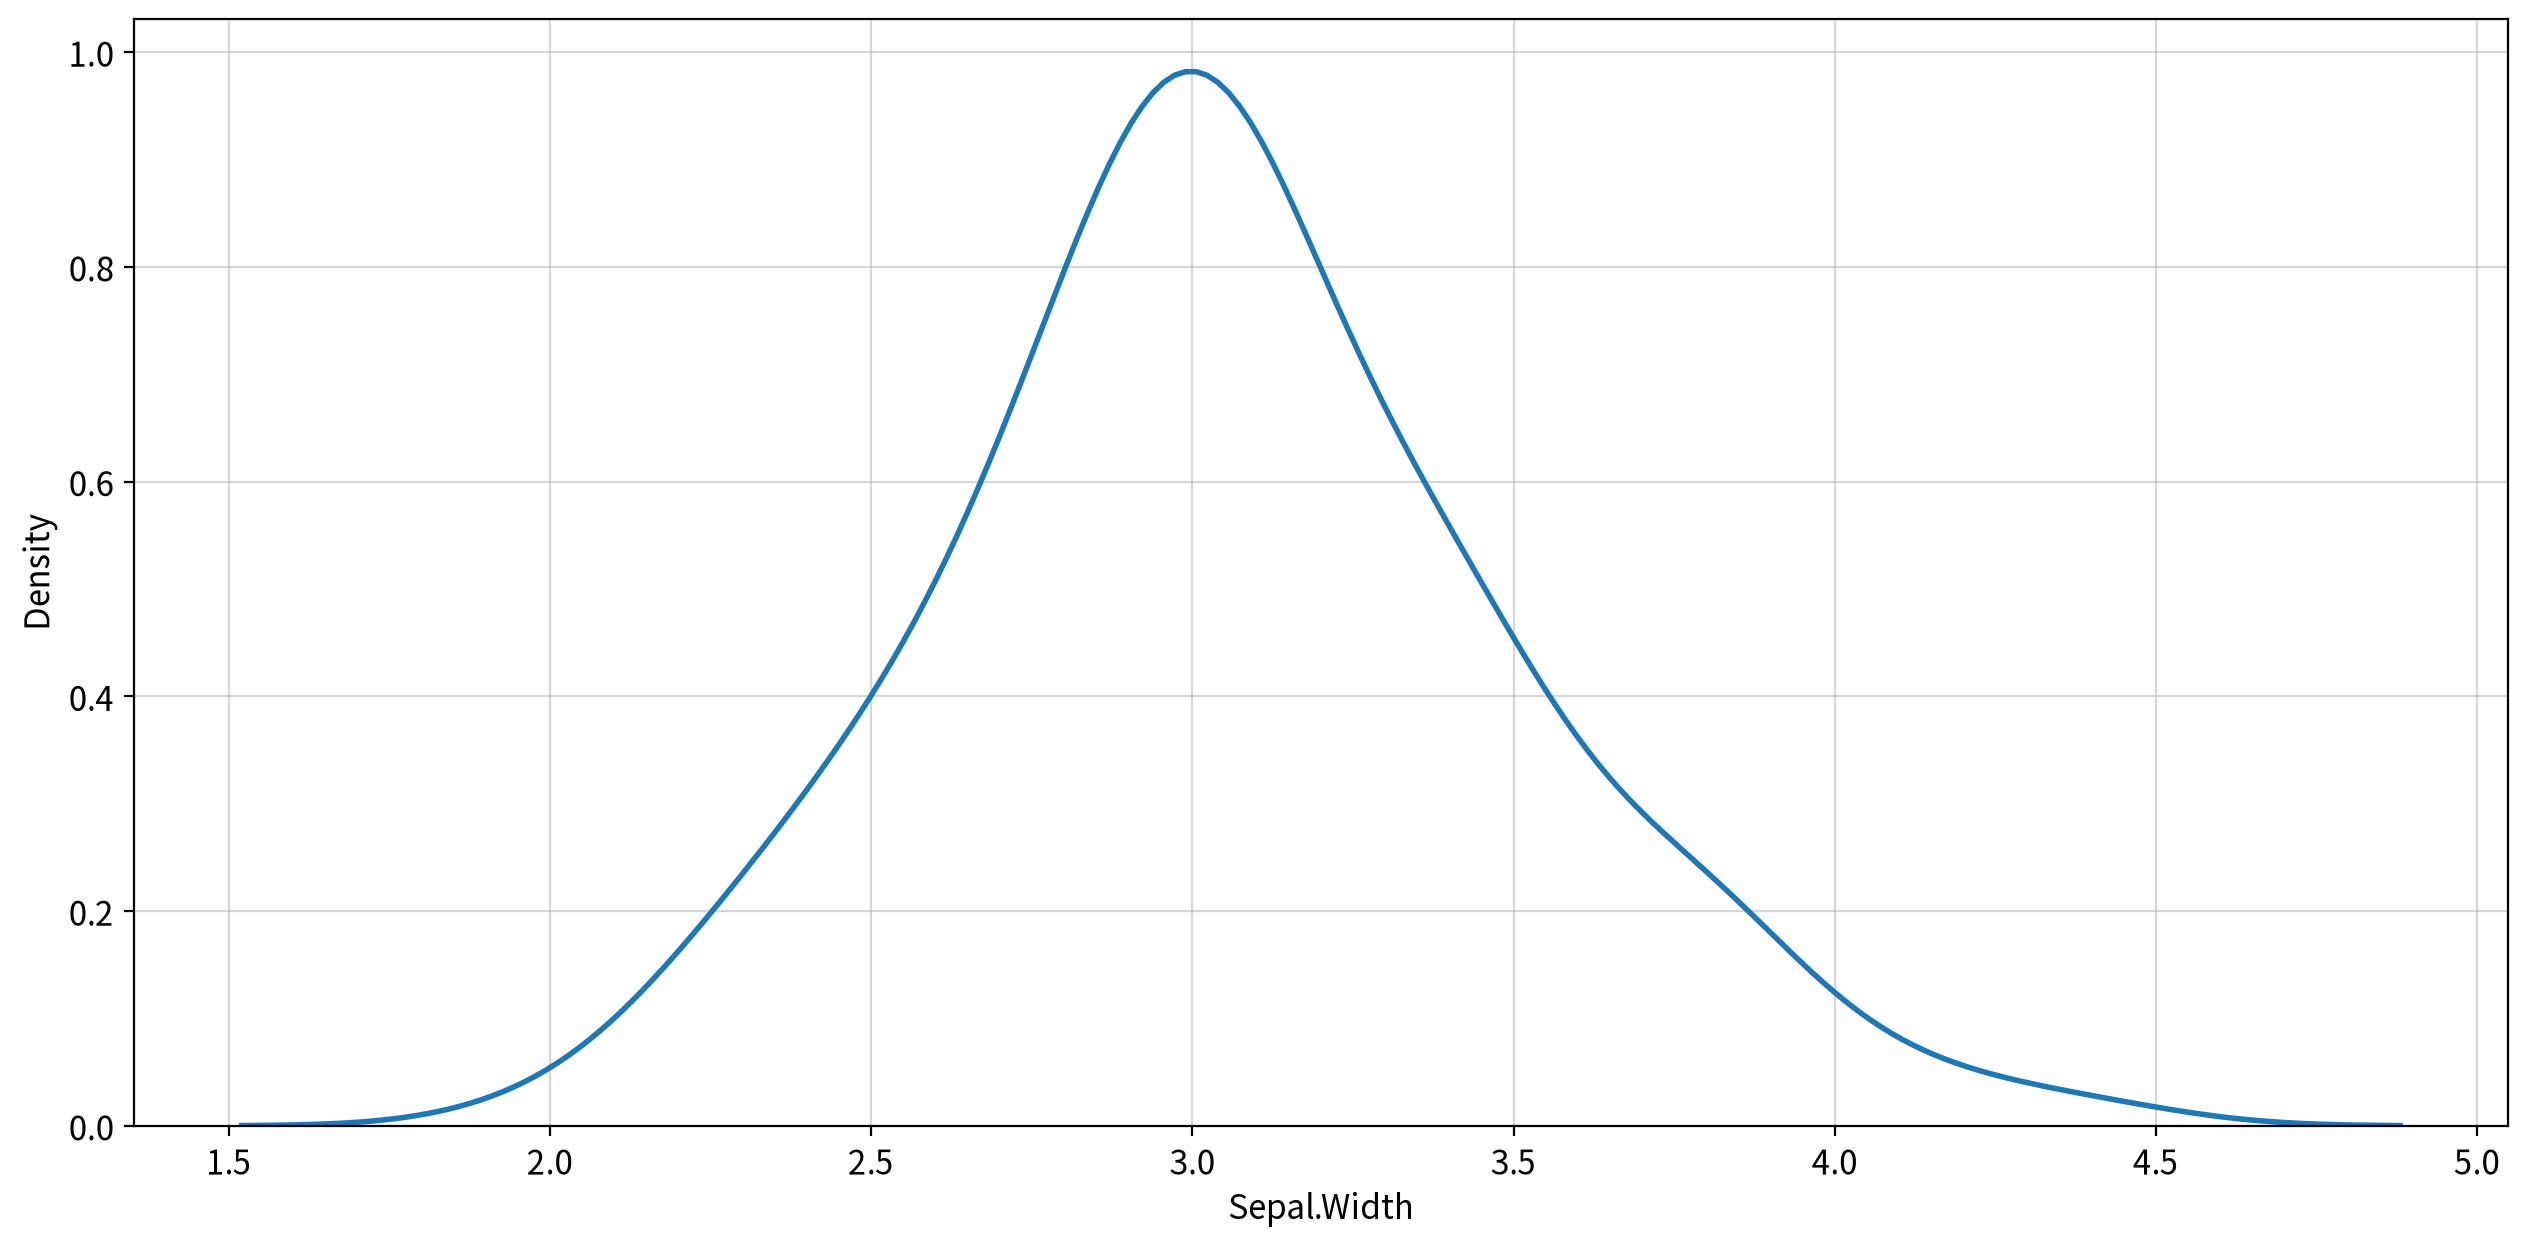

In [9]:
my_plot.kdeplot(data=origin, x="Sepal.Width")

### 2. 제목, 라벨, 평균선 표시 / 색상 채우기

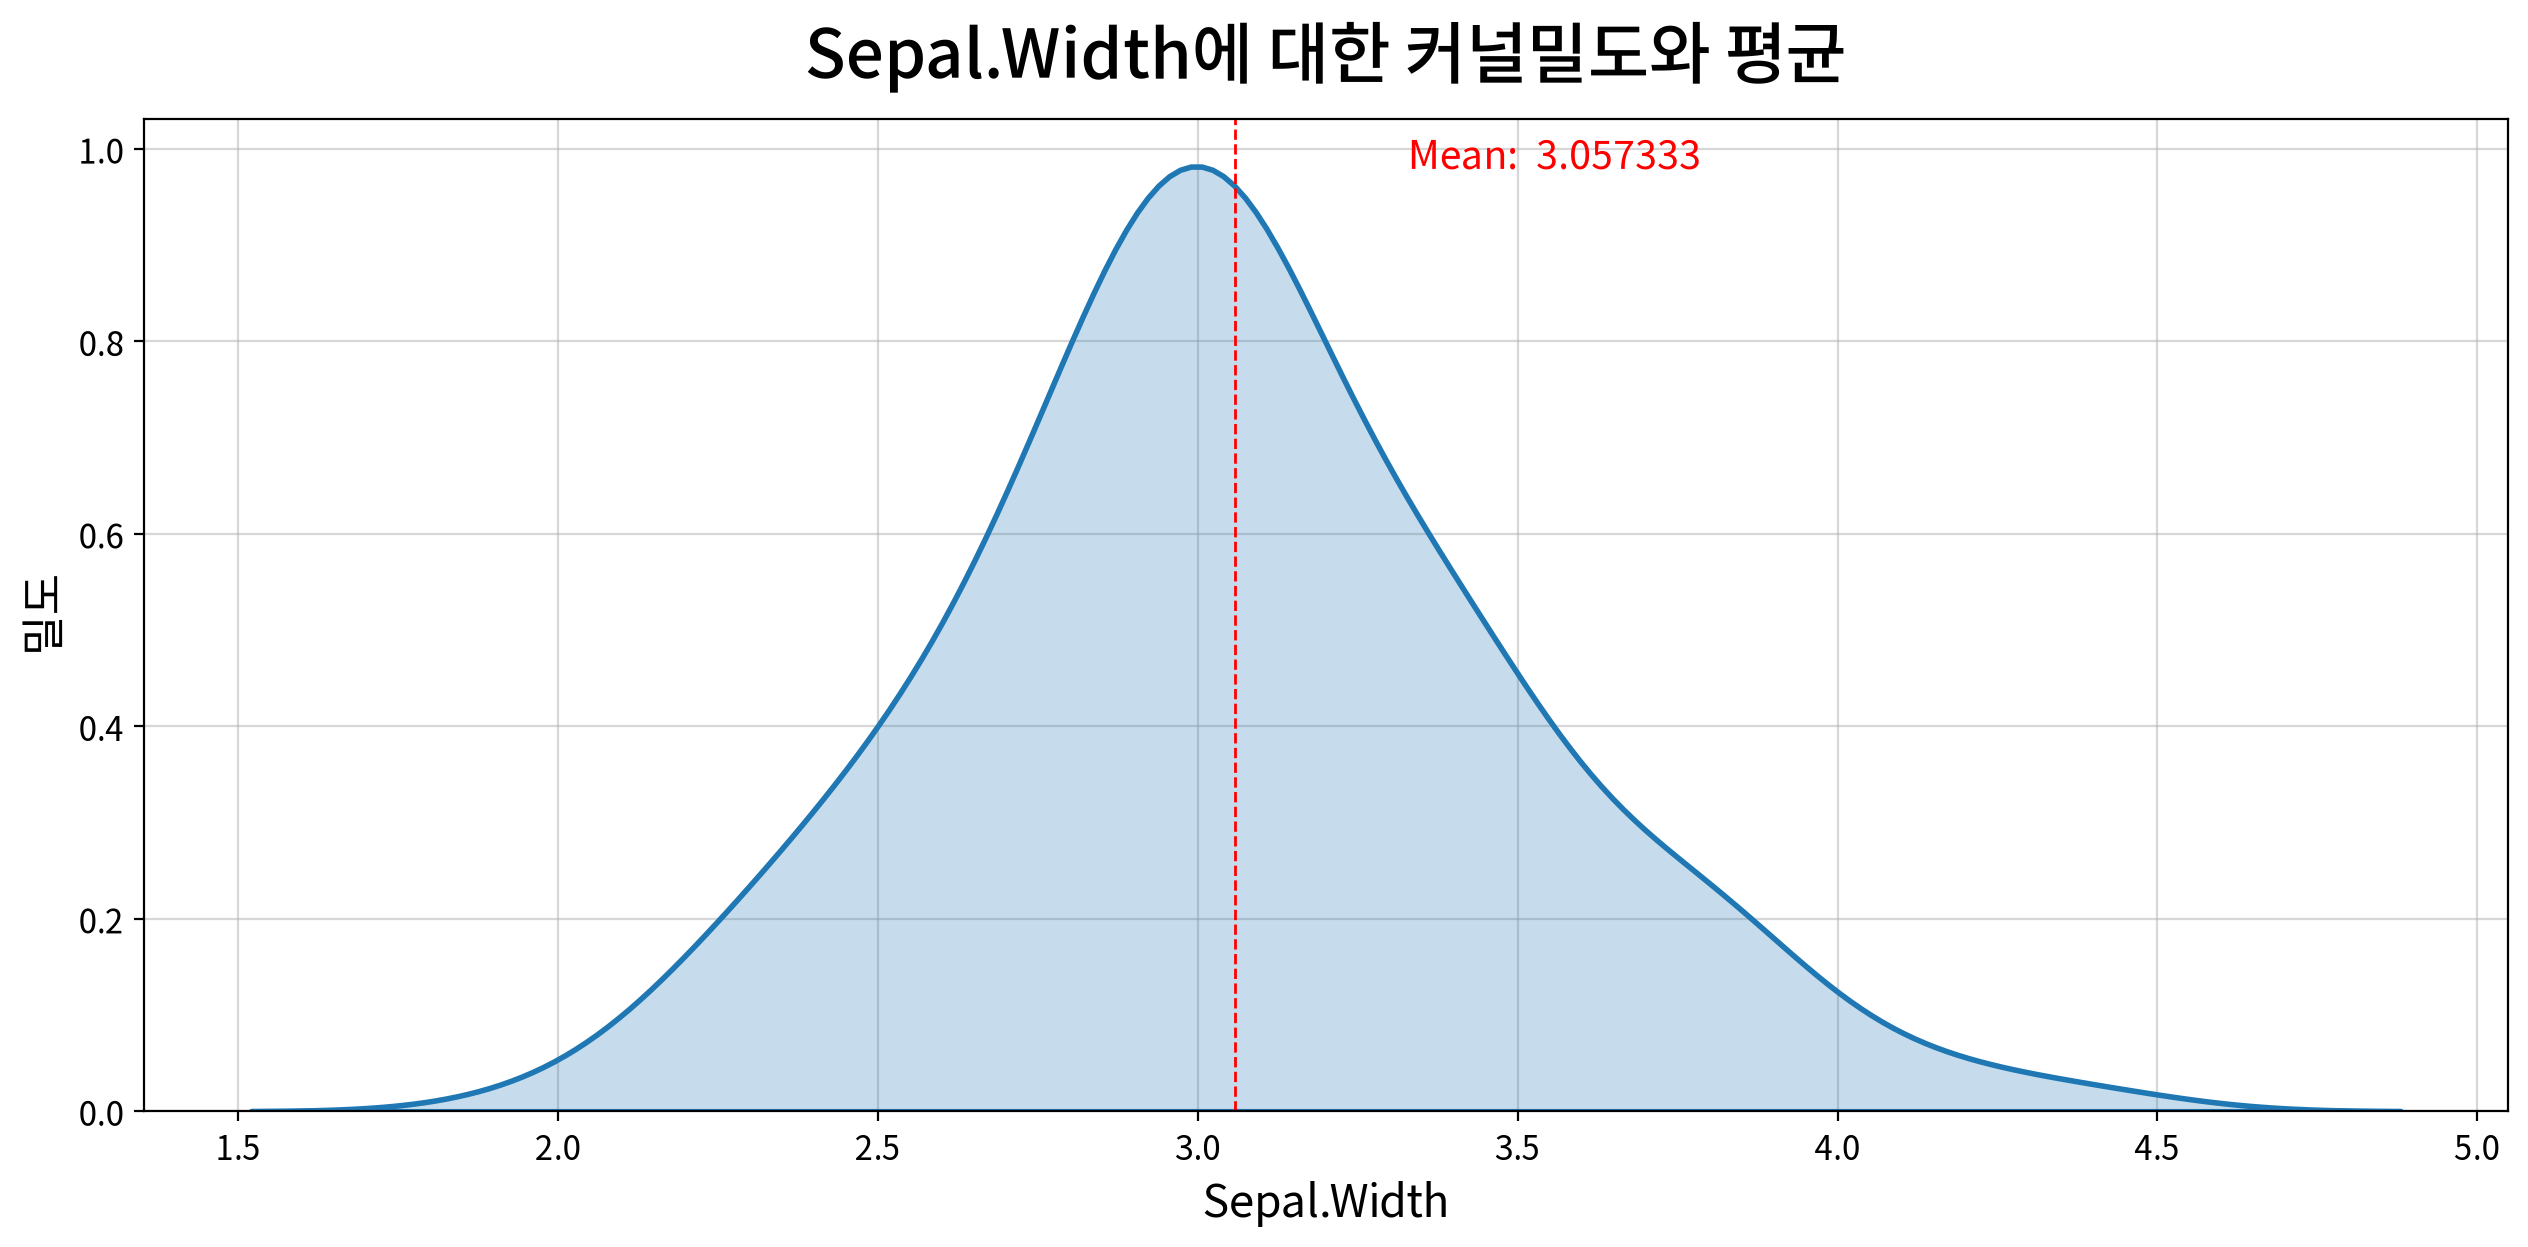

In [10]:
my_plot.kdeplot(title="Sepal.Width에 대한 커널밀도와 평균", xlabel="Sepal.Width", ylabel="밀도", data=origin, x="Sepal.Width", meanline=True, fill=True)

### 3. 범주에 따른 구분

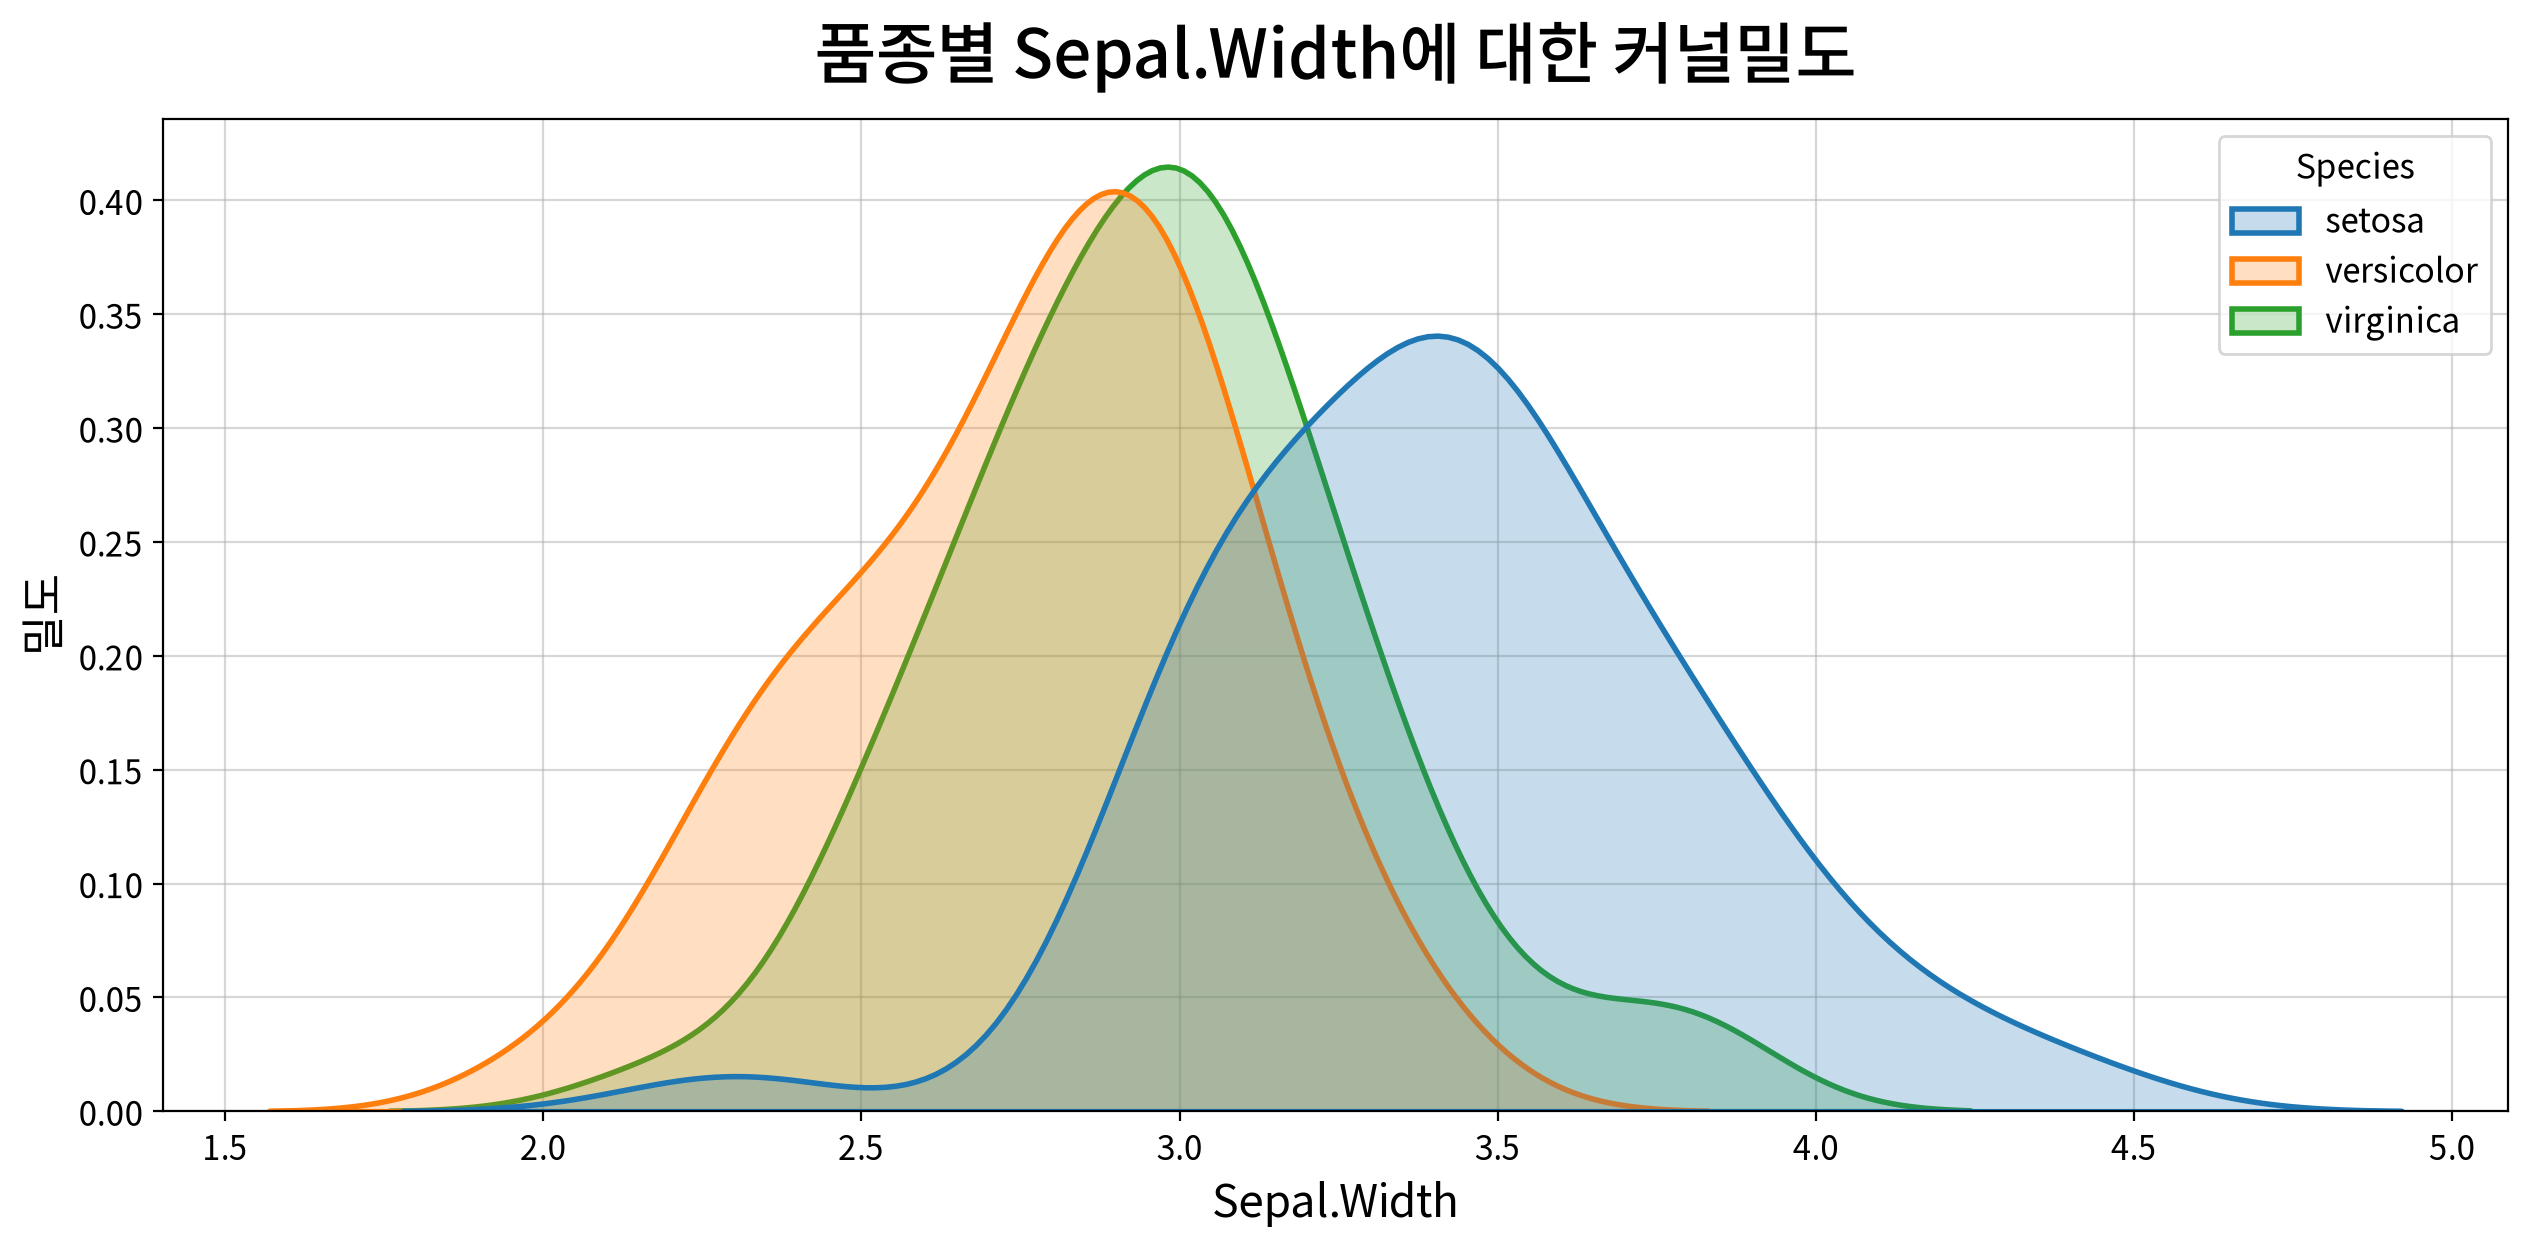

In [11]:
my_plot.kdeplot(data=origin, title="품종별 Sepal.Width에 대한 커널밀도", xlabel="Sepal.Width", ylabel="밀도", x="Sepal.Width", hue='Species', fill=True)

### 4. 범주에 따른 구분 + 평균선

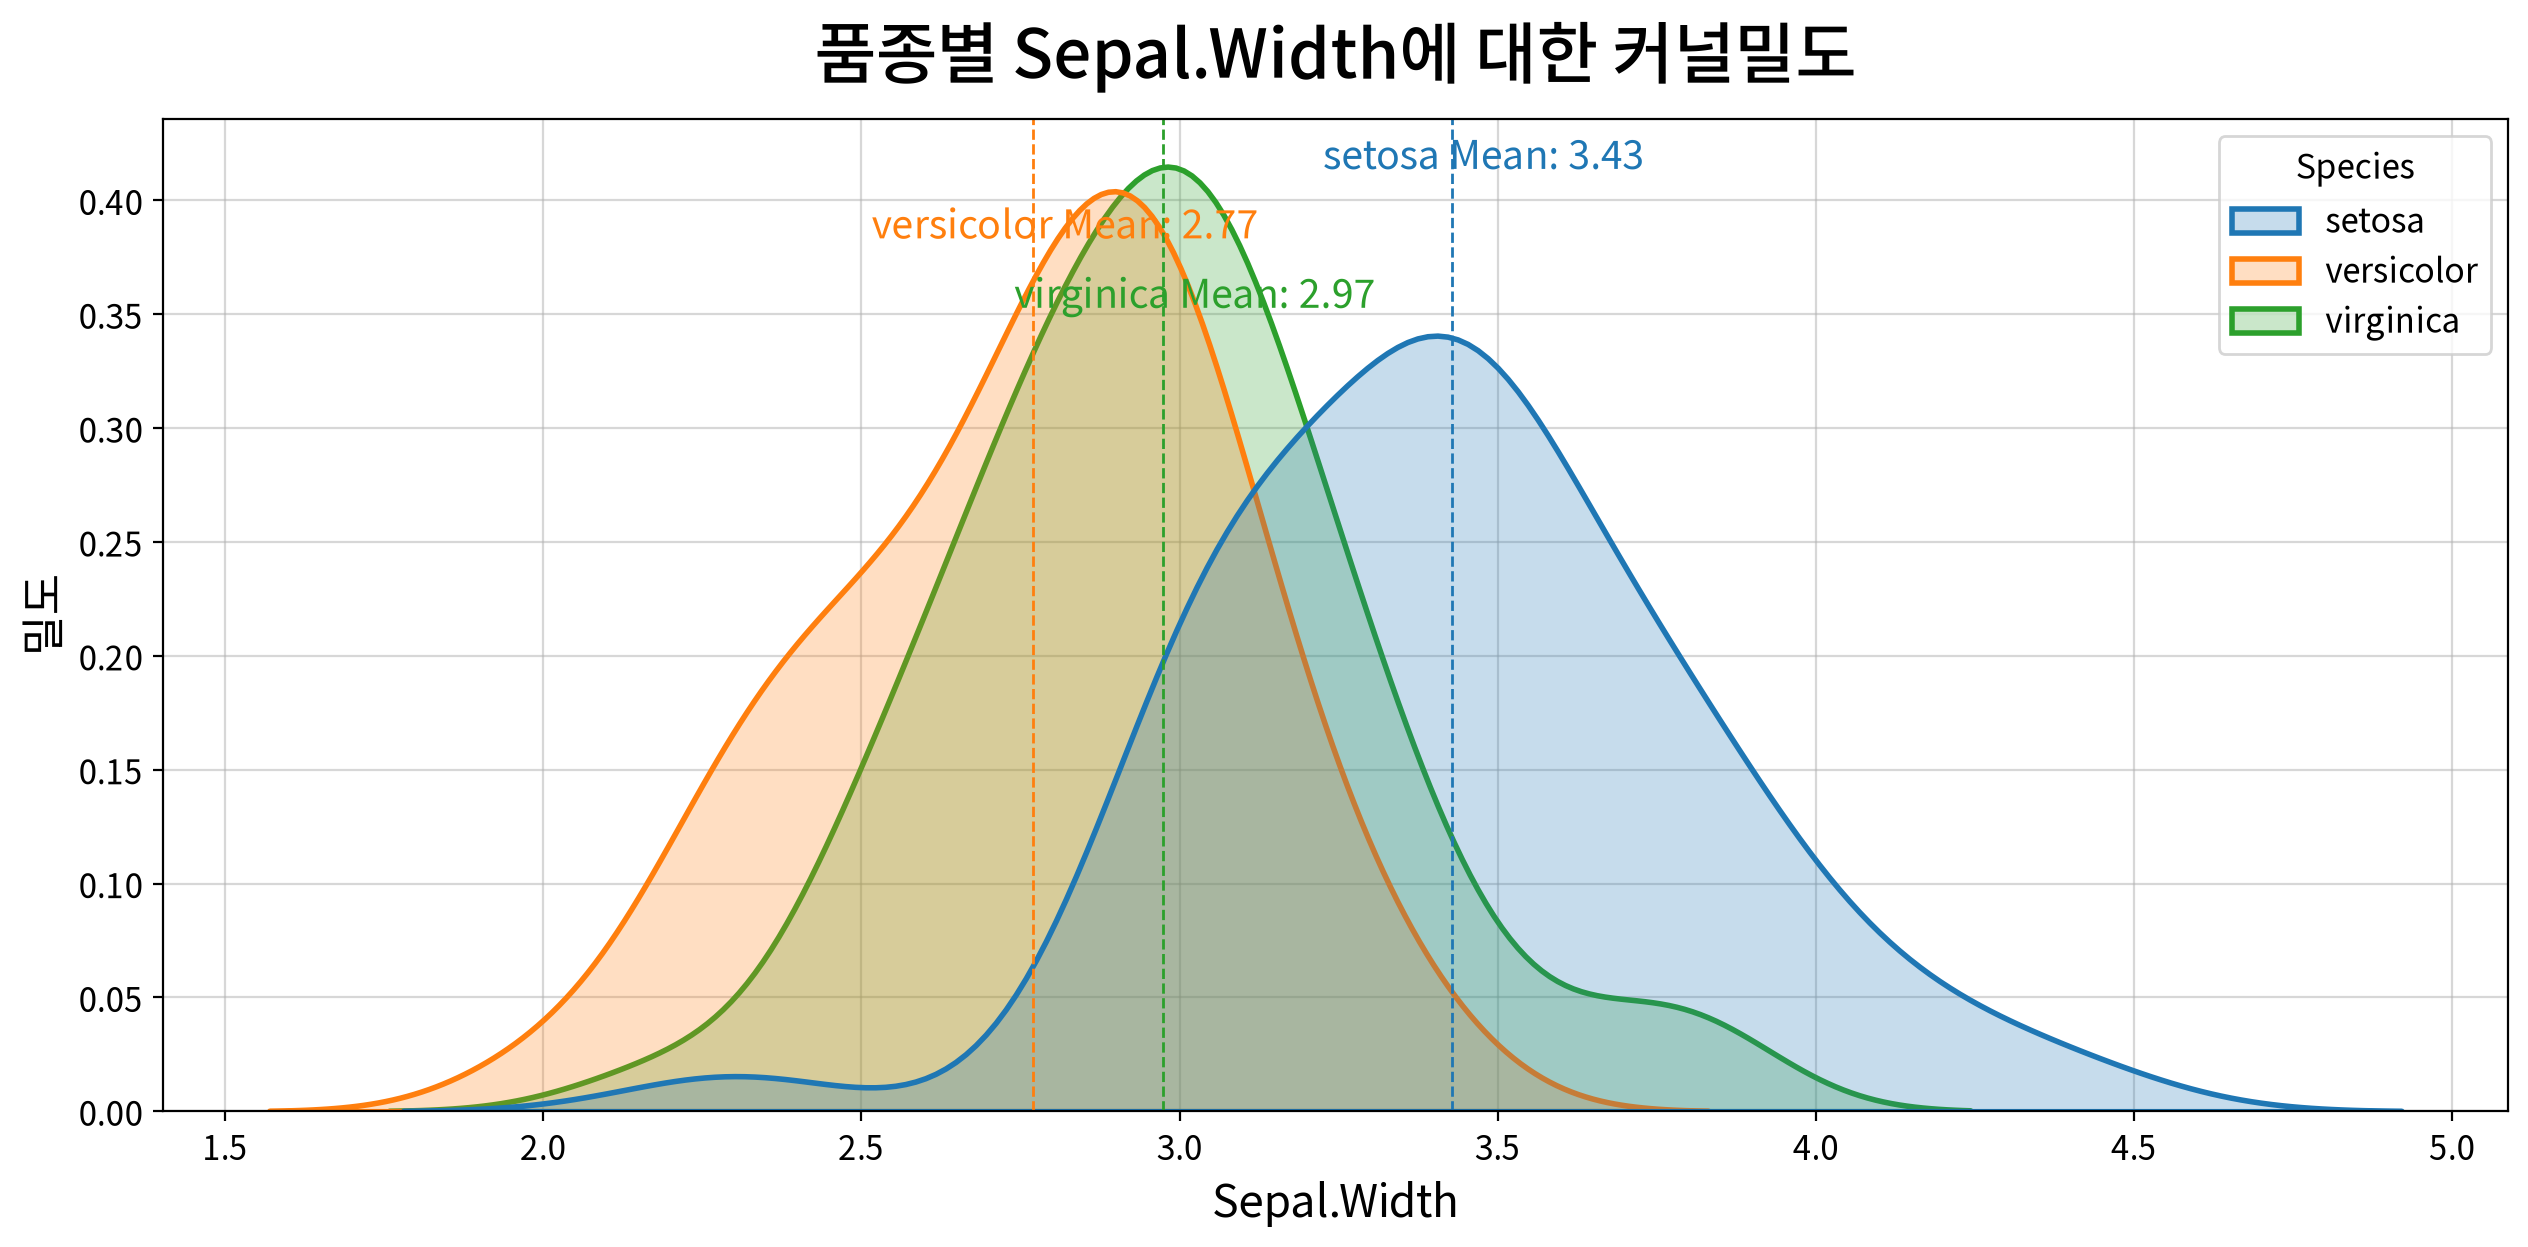

In [12]:
my_plot.kdeplot(title="품종별 Sepal.Width에 대한 커널밀도", xlabel="Sepal.Width", ylabel="밀도", data=origin, x="Sepal.Width", hue='Species', fill=True, meanline=True)

##### analysis_grade데이터는 통계학개론을 수강하는 두 학과(A,C)의 성적을 조사한 데이터이다.
##### 이 데이터를 활용하여 각 학과의 성적 분포에 대한 KDEPlot을 시각화하고 물음에 답하시오.
##### 시각화 결과물은 두개가 나와야함.

In [15]:
# 0.모듈 불러오기
from jussam import load_data
from helper import *
import seaborn as sb

In [27]:
# 1.데이터 불러오기
grade = load_data('analysis_grade')
grade.info()
grade
gradeA = grade[grade['학과']=='A']
gradeC = grade[grade['학과']=='C']
gradeA
gradeC

📚 통계학개론을 수강하는 두 학과(A, C)의 성적분포 데이터의 일부 (출처: 방송통신대학교 통계학개론 수업내용에서 발췌)
<class 'pandas.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   학과      32 non-null     str  
 1   점수      32 non-null     int64
dtypes: int64(1), str(1)
memory usage: 676.0 bytes


,학과,점수
0,C,54
3,C,41
5,C,43
7,C,51
8,C,55
10,C,52
14,C,48
16,C,51
17,C,82
24,C,90


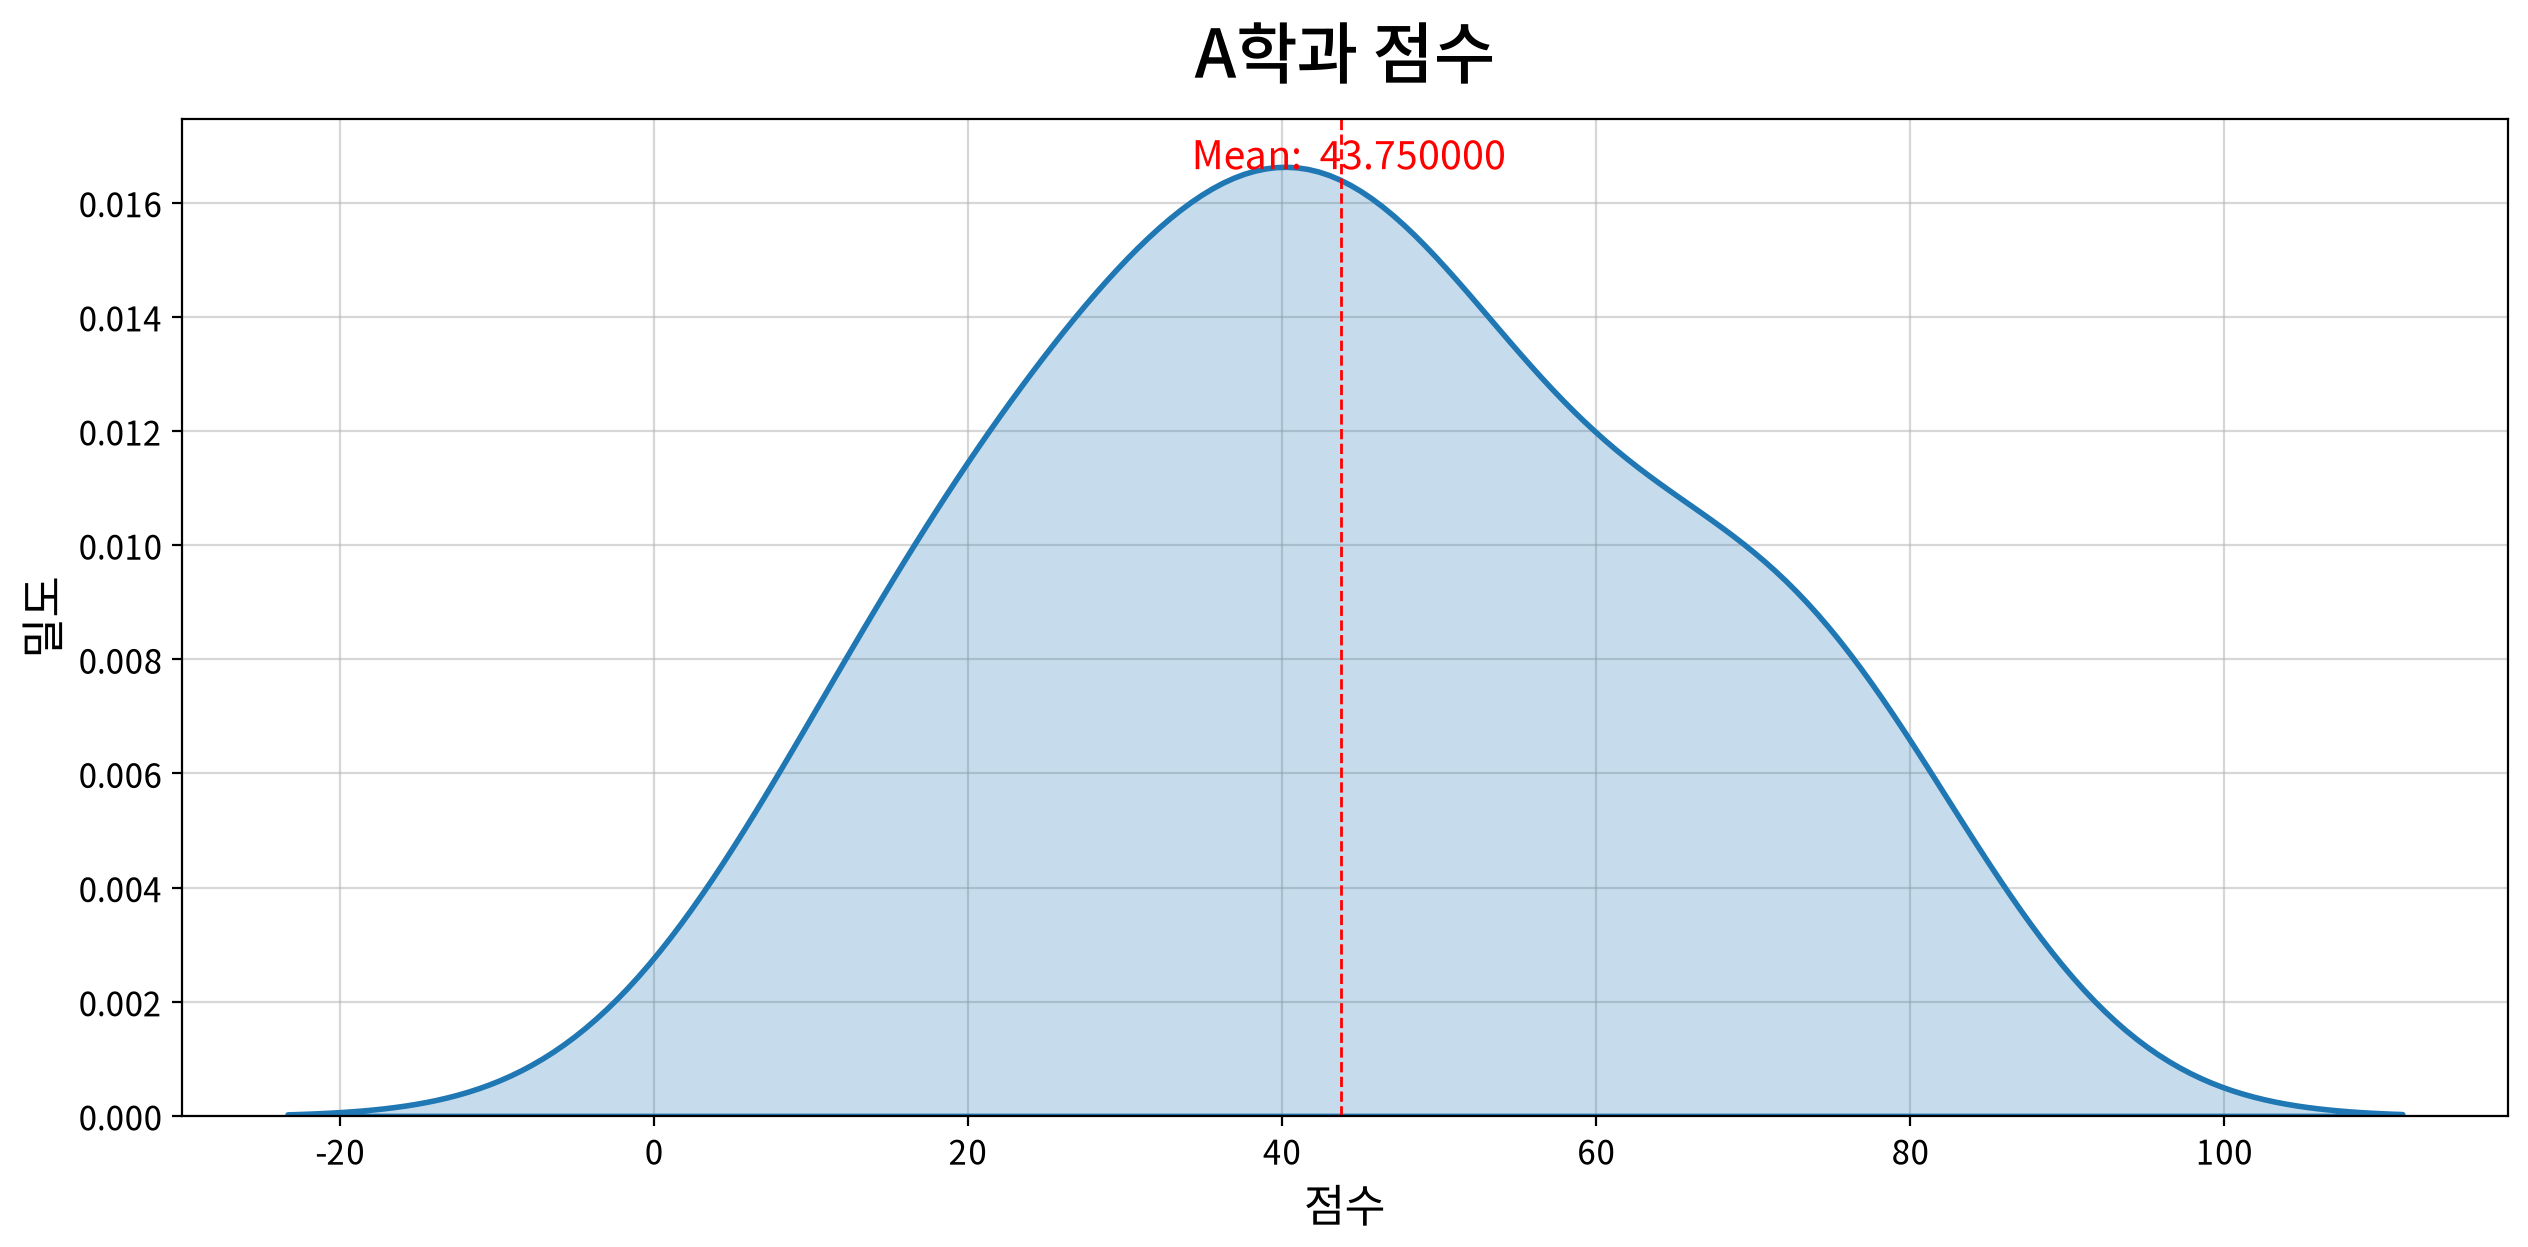

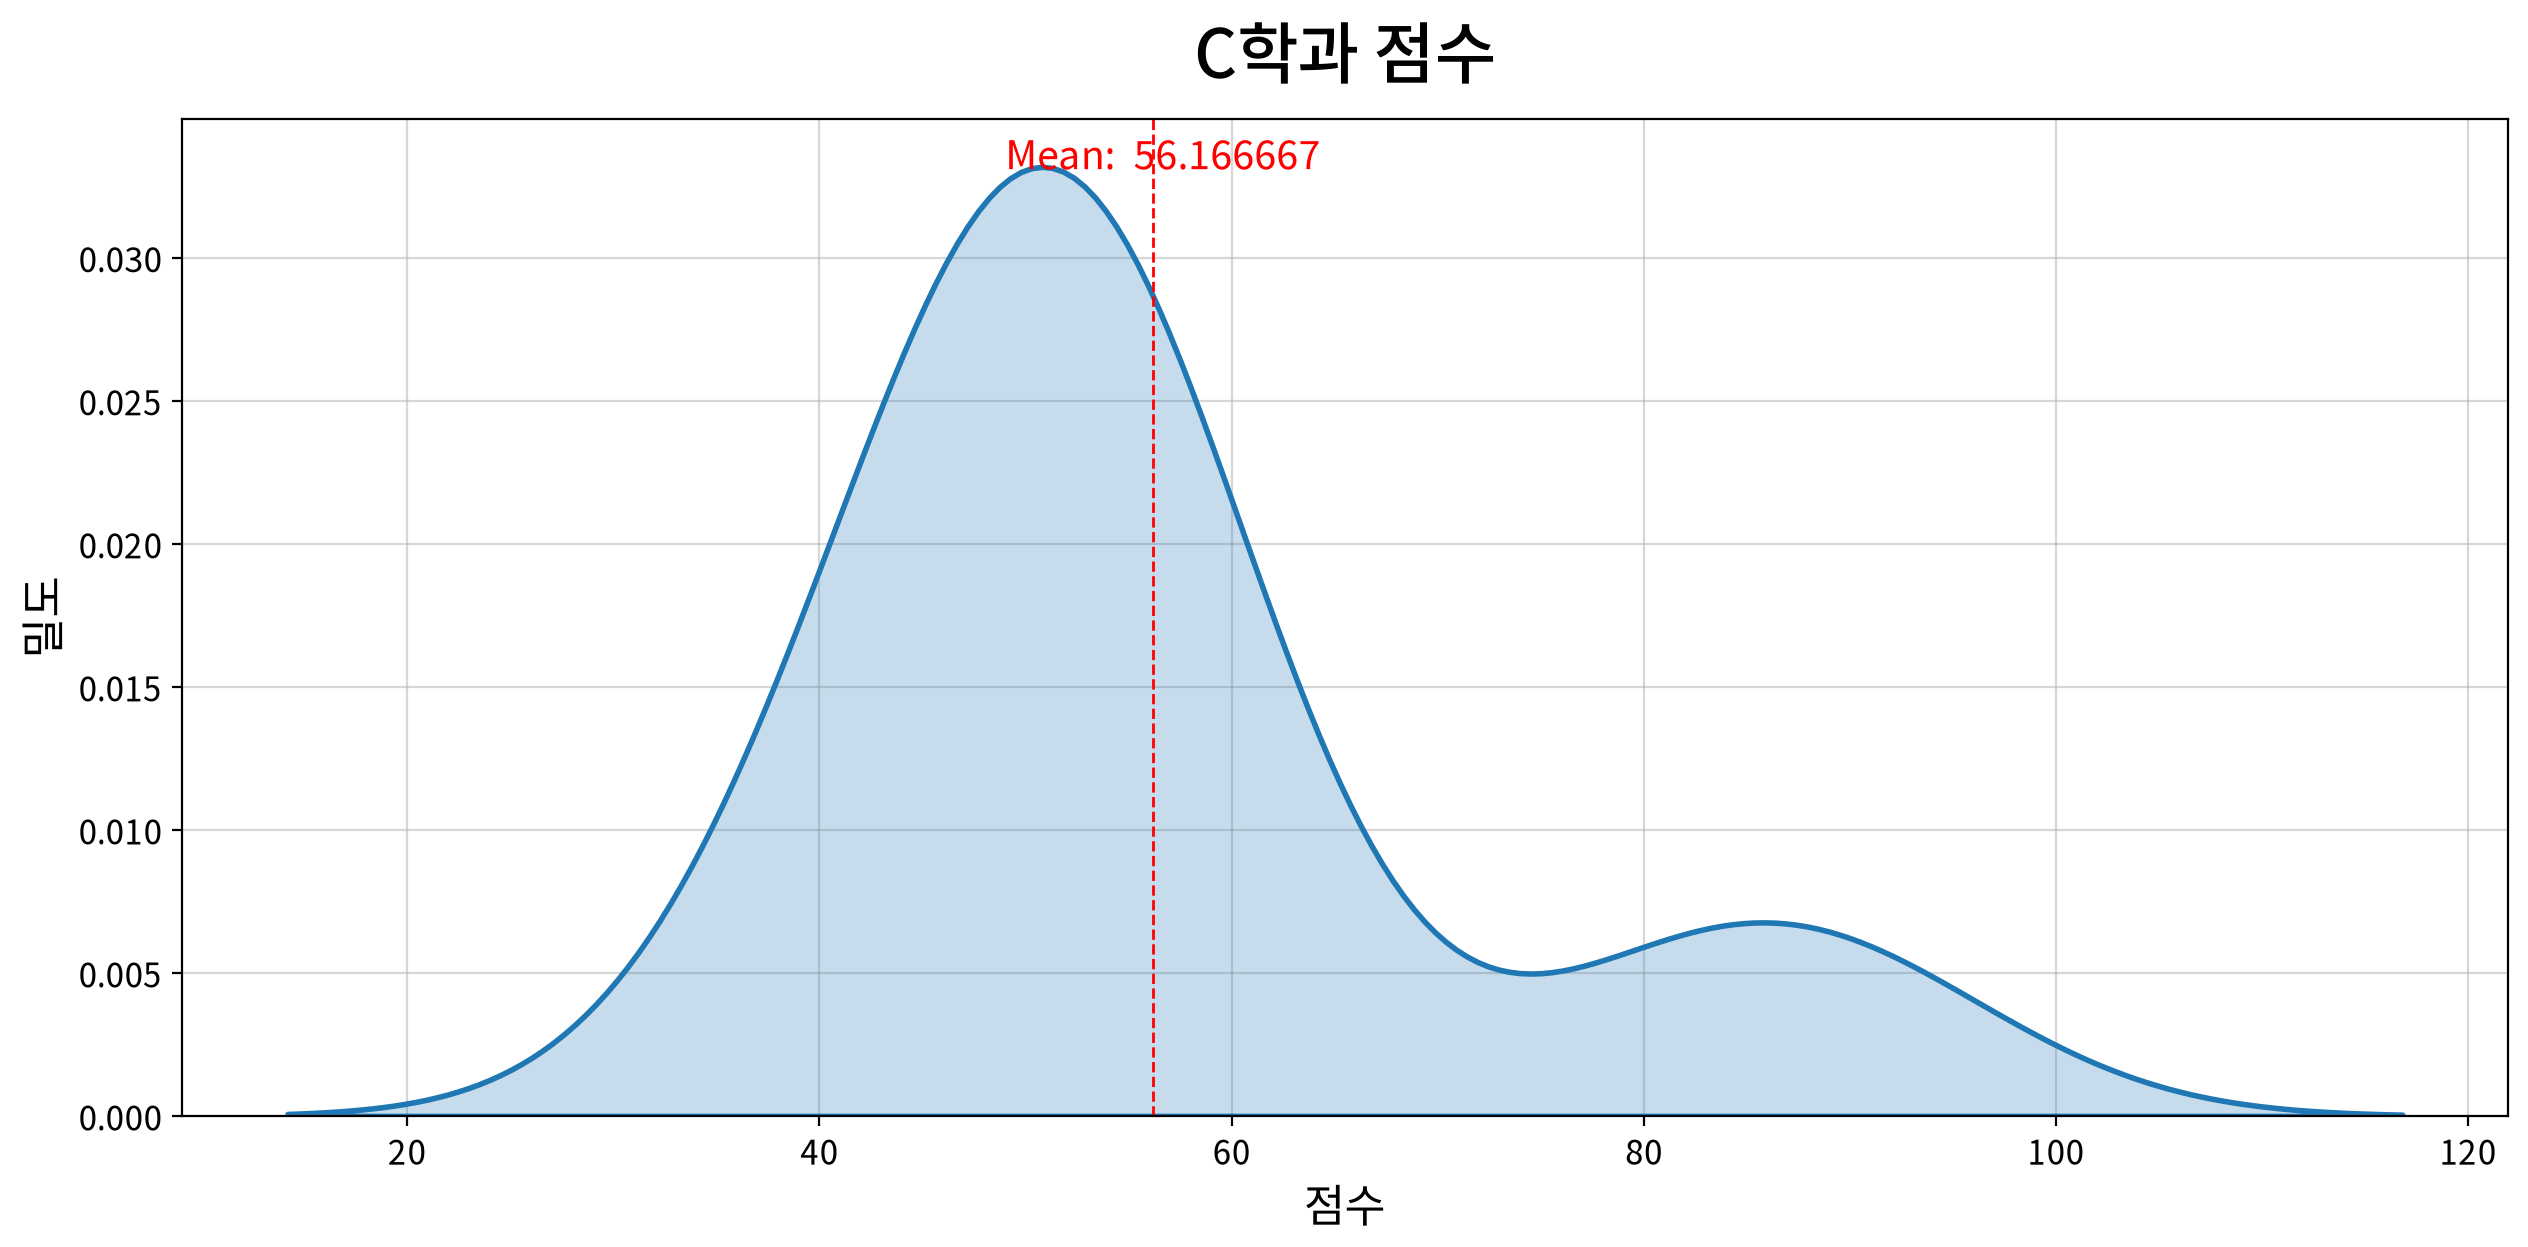

In [35]:
my_plot.kdeplot(data=gradeA, title="A학과 점수", x="점수", xlabel="점수", ylabel="밀도", meanline=True, fill=True)
my_plot.kdeplot(data=gradeC, title="C학과 점수", x="점수", xlabel="점수", ylabel="밀도", meanline=True, fill=True)

##### 문 제 1. A학과와 C학과 중 평균점수가 더 높은 학과는?
###### 두 그래프의 Mean(평균값)을 보면 C학과가 56.16667 A학과가 43.75로 C학과가 평균점수가 높다.

##### 문 제 2. C학과의 점수 분포에서 관찰되는 봉우리(peak)의 개수는?
###### 그래프에서 50점대, 90점대에 봉우리가 두개가 보임.

##### 문 제 3. A학과와 C학과 중 점수가 더 넓게 퍼져있는(산포가 큰) 학과는?
###### 이건 따로 코드 해볼것!!!!!!!!!!!!!!!
###### 그래프로 보면 A학과가 점수가 C학과보다 더 넓게 퍼져있음.

##### 문 제 4. C학과의 KDE평균(56.17)이 최빈값(약50점)보다 큰 위치에 있다. 이로 알수있는 분포의 왜도(skewness)는?
###### 이것도 따로 코드로 해볼것!!!!!!!!!!!!!!
###### 평균값>최빈값이므로 오른쪽 꼬리가 긴 양의 분포이다.

##### 문 제 5. 두 학과 중 '평균값'을 성적의 대표값으로 사용하기에 더 적합한 학과는?
###### A학과가 분포가 중앙에 몰려있어 A학과가 더 적합하다.